# 🗣️ Language Models (LMs)

[Sam Foreman](https://samforeman.me)
(\[[ALCF](https://alcf.anl.gov/about/people/sam-foreman)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2025-08-05

> **Authors**
>
> Content by Archit Vasan, including materials on LLMs by Varuni Sastri
> and Carlo Graziani at Argonne, and discussion/editorial work by Taylor
> Childers, Bethany Lusch, and Venkat Vishwanath (Argonne). Modified by
> Huihuo Zheng (Aug 1, 2025).

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/02-llms/00-intro-to-llms/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/02-llms/00-intro-to-llms/index.qmd)

Although the term *“language model”* comes from Natural Language
Processing, the same machinery applies to a surprisingly broad range of
**scientific** problems. This session builds up the core ideas of
sequential-data modeling and the key architectural element behind modern
LLMs: the **Transformer**.

> **🎯 Learning objectives**
>
> By the end of this session you will be able to:
>
> 1.  Explain what **sequential data** is and why it shows up across
>     science.
> 2.  Trace the **evolution** of language models from RNNs to
>     Transformers.
> 3.  Describe **tokenization** and **embeddings** — how text becomes
>     numbers.
> 4.  Explain the **attention mechanism** and the anatomy of a
>     Transformer block.
> 5.  Understand the **training objective** (cross-entropy) and
>     **perplexity**.
> 6.  Build a **mini-LLM from scratch** and recognize the major
>     Transformer families.
> 7.  Run a **pretrained model** end-to-end with 🤗 HuggingFace.

> Inspired by Jay Alammar’s superb [The Illustrated
> Transformer](https://jalammar.github.io/illustrated-transformer/) and
> [The Illustrated GPT-2](https://jalammar.github.io/illustrated-gpt2/)
> — highly recommended companion reading.

## 🧬 Why Sequences? Motivation from Science

Before the math, the motivation. A **sequence** is an ordered list whose
elements depend on what came before (and sometimes after). Language is
the obvious example — but so is much of science.

<figure id="fig-seq-applications">
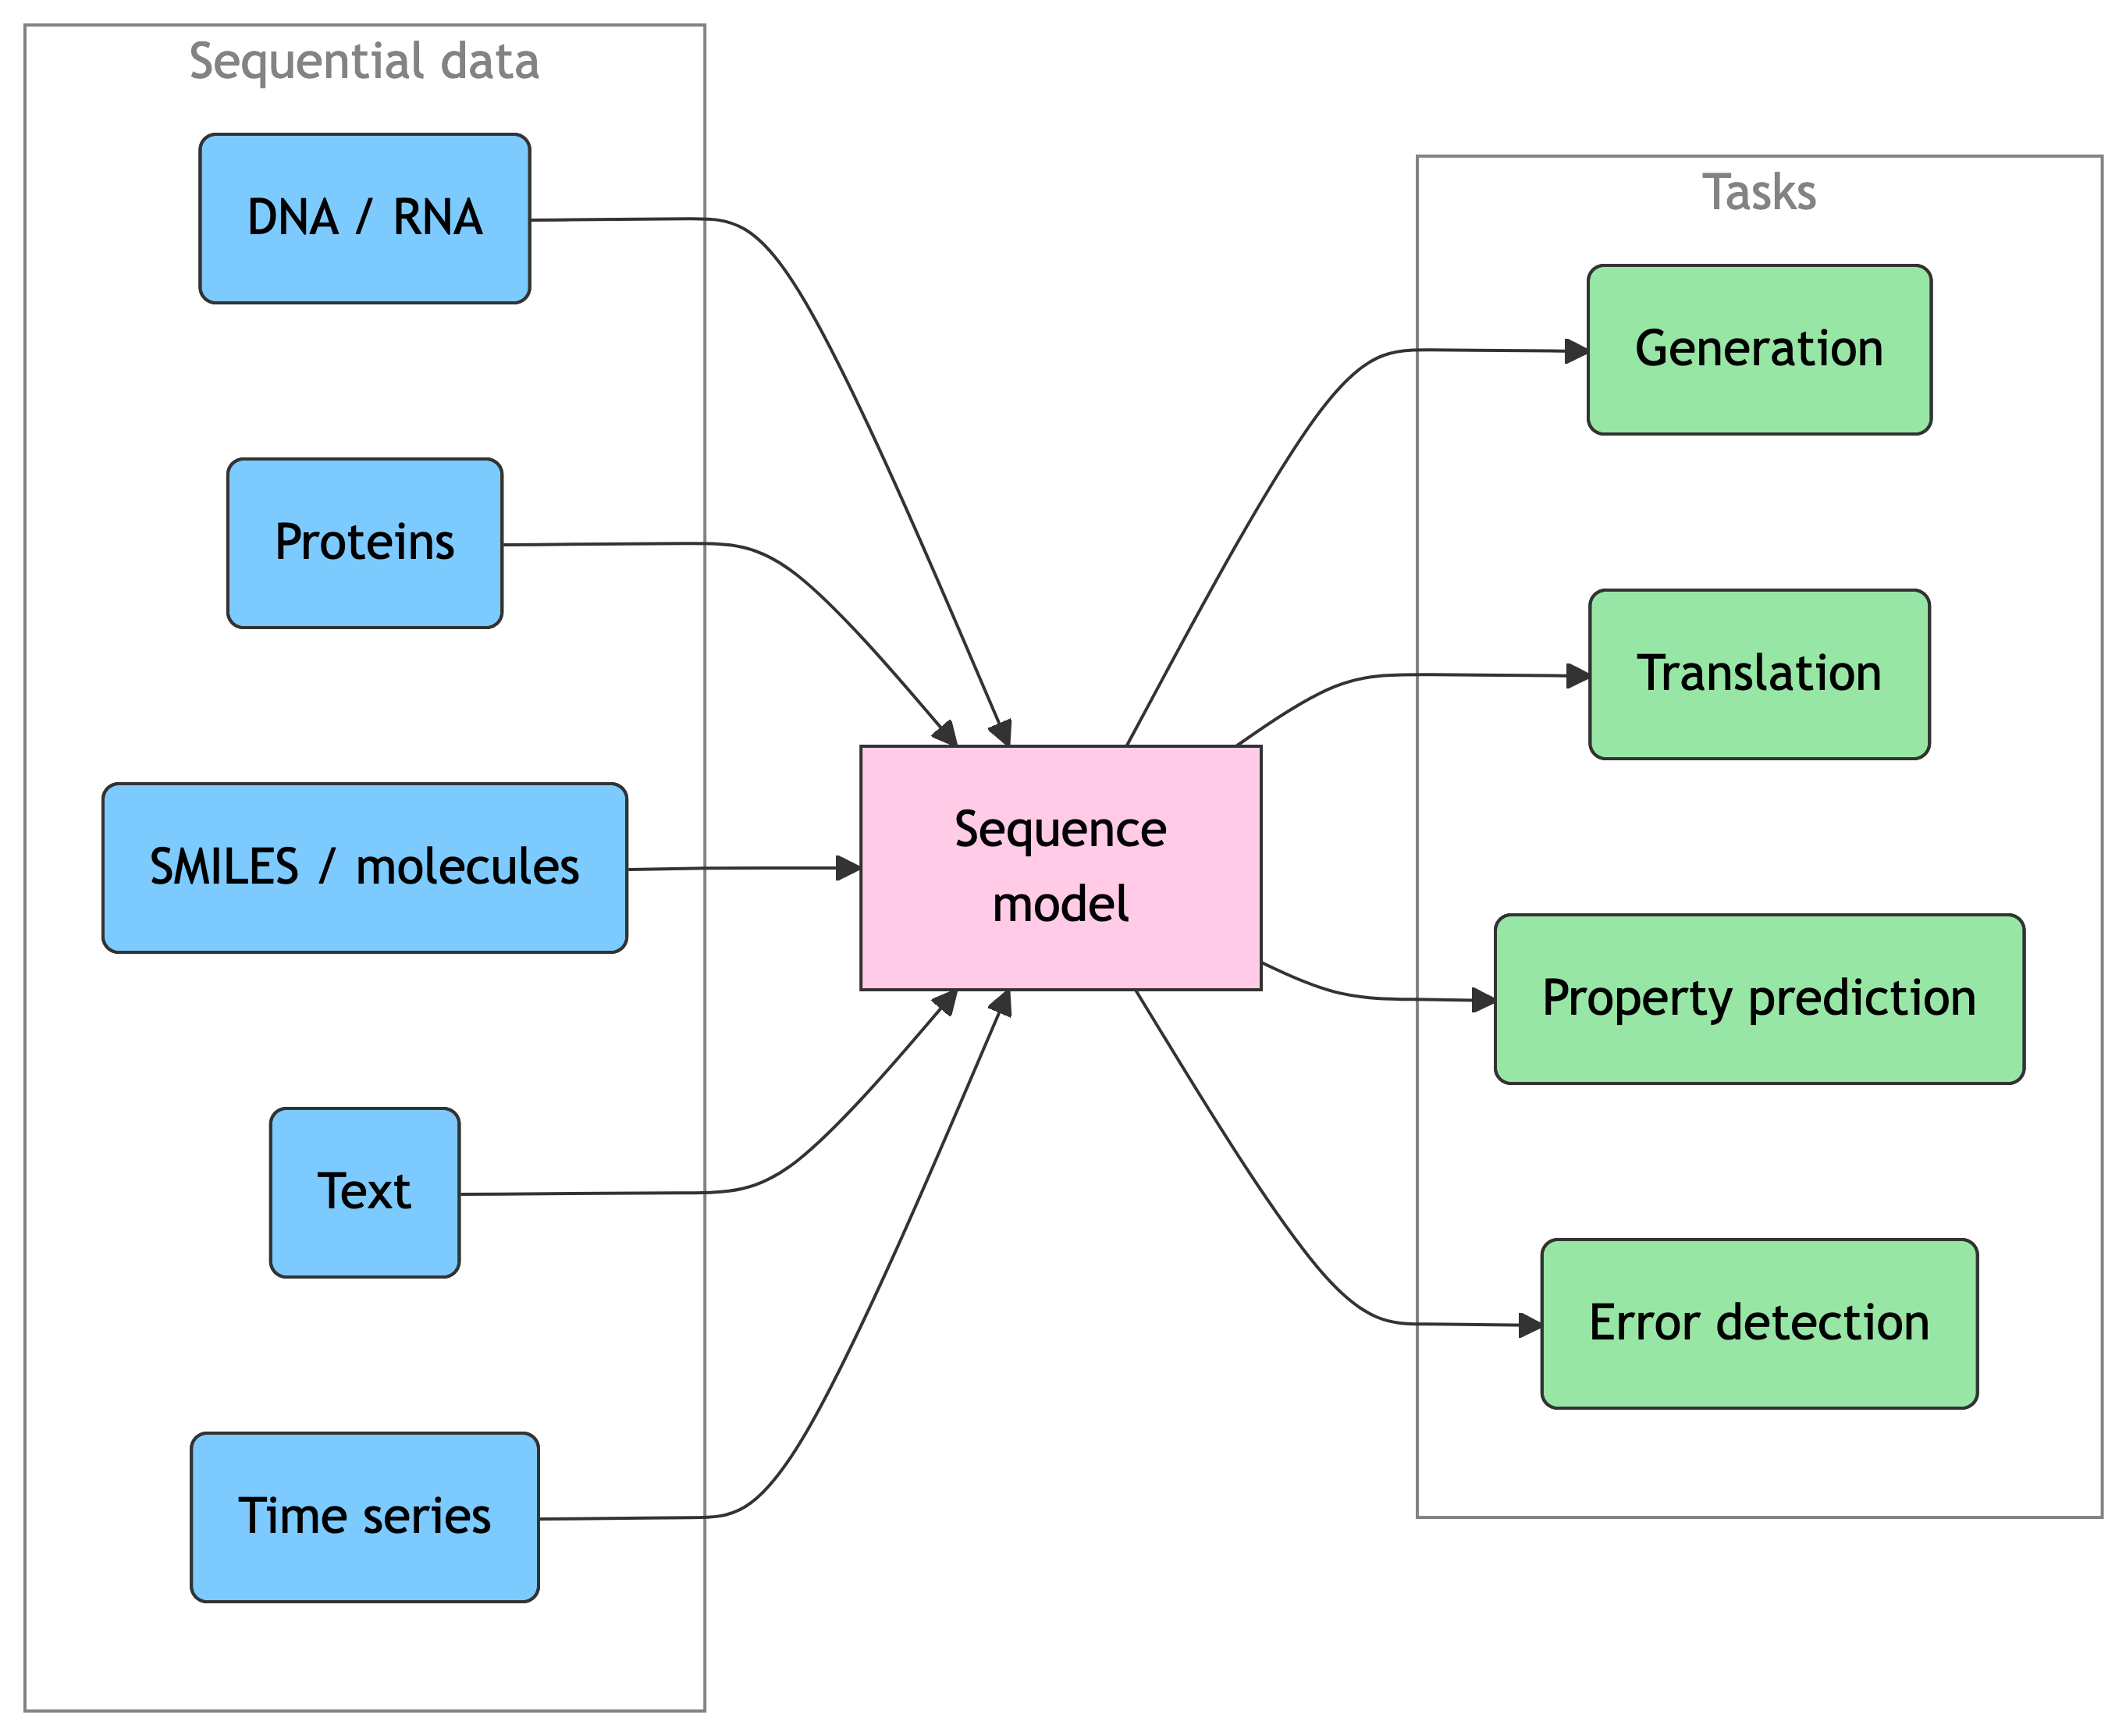
<figcaption>Figure 1: One model family, many modalities. The same
sequence-modeling tools power text generation <em>and</em> scientific
discovery.</figcaption>
</figure>

### Scientific examples

**Nucleic-acid & genomic data.** DNA/RNA sequences predict protein
translation, mutations, and gene expression.

<figure id="fig-rna-sequences">
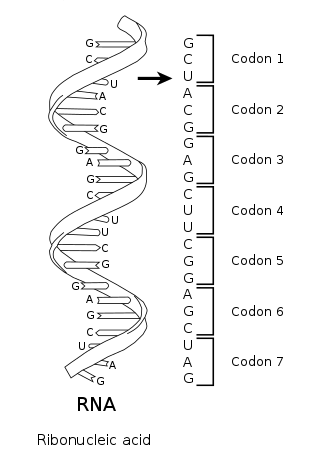
<figcaption>Figure 2: RNA codon structure.</figcaption>
</figure>

[GenSLM](https://www.biorxiv.org/content/10.1101/2022.10.10.511571v1), a
genomic language model developed at Argonne, modeled the evolution of
SARS-CoV-2 — capturing viral variant dynamics *without* expensive
wet-lab experiments.

<figure id="fig-genslm">
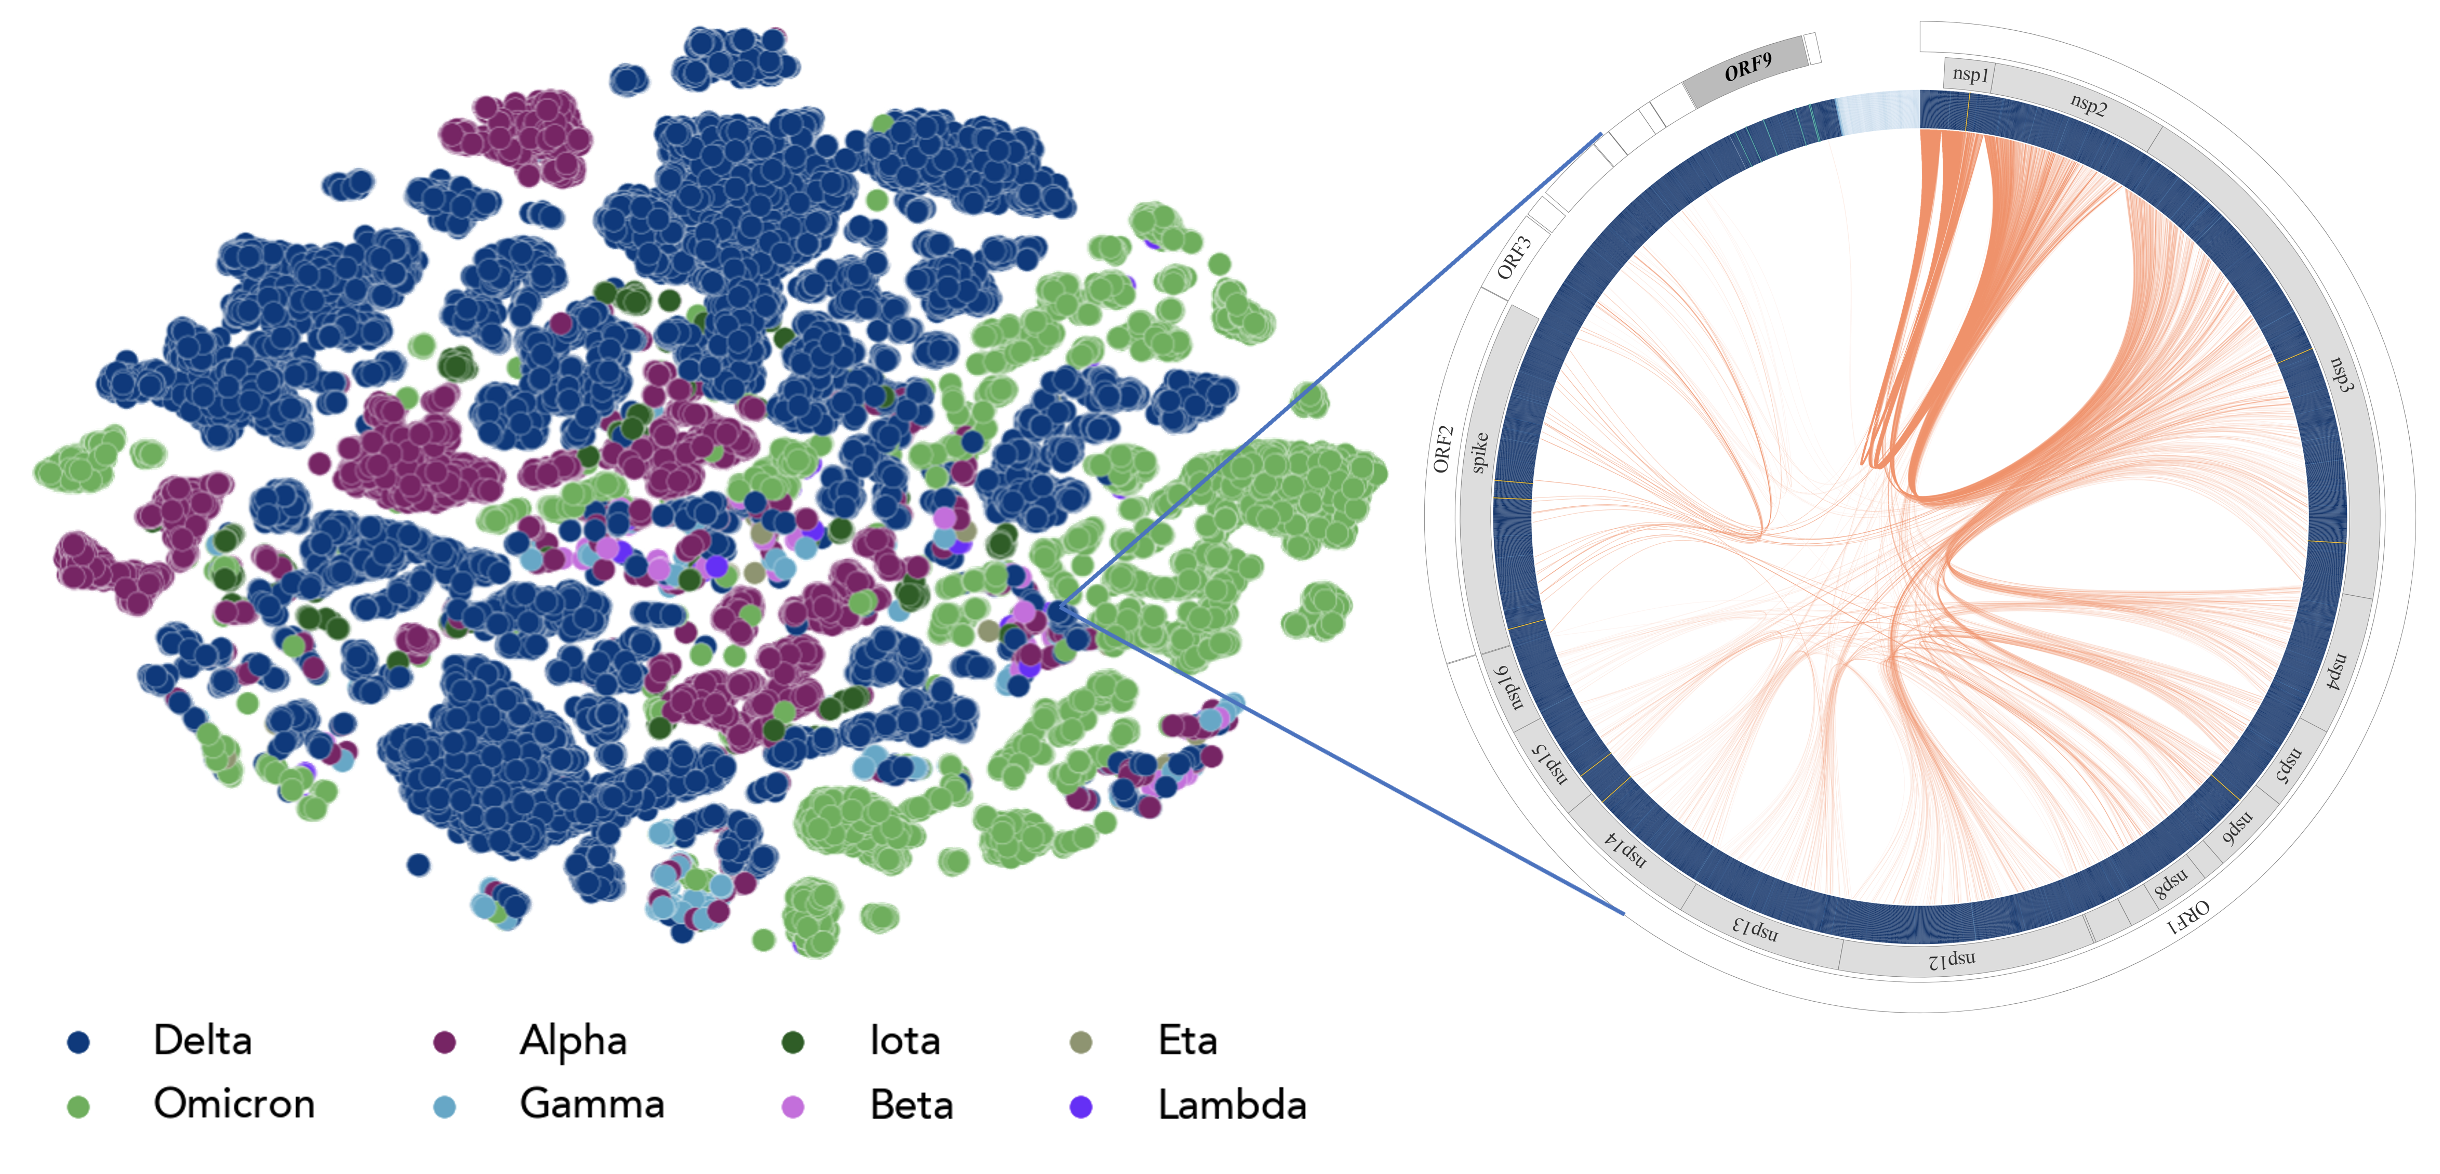
<figcaption>Figure 3: GenSLM. Image credit: Zvyagin et al. 2022,
bioRxiv.</figcaption>
</figure>

**Protein sequences** predict folding structure, protein–protein
interactions, binding properties, and function.

<figure id="fig-protein-sequences">
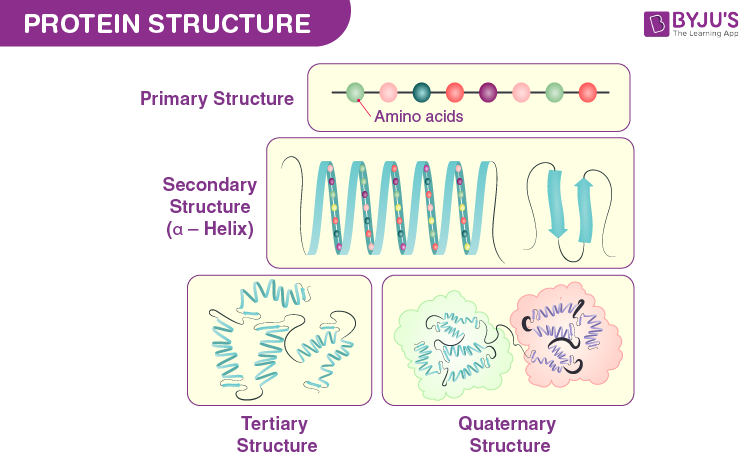
<figcaption>Figure 4: Protein sequences.</figcaption>
</figure>

Other active areas include **biomedical text**, **SMILES strings**
(molecules), **weather prediction**, and **coupling to simulations**
such as molecular dynamics.

### Formalizing sequence modeling

Mathematically, a sequence is an ordered list of **tokens**:

$$T = [t_1, t_2, t_3, \ldots, t_N]$$

The central object is the probability of a token given its context. An
autoregressive language model factorizes the joint probability of the
whole sequence into a product of next-token predictions:

$$P(T) = \prod_{i=1}^{N} P(t_i \mid t_1, t_2, \ldots, t_{i-1})$$

Learning these conditional distributions is what lets a model
**generate** (sample the next token), **translate** (map one sequence to
another), **predict properties** (condition on the whole sequence), and
**spot errors** (flag low-probability tokens).

## 📜 A Brief History of Language Models

<figure id="fig-lm-history">
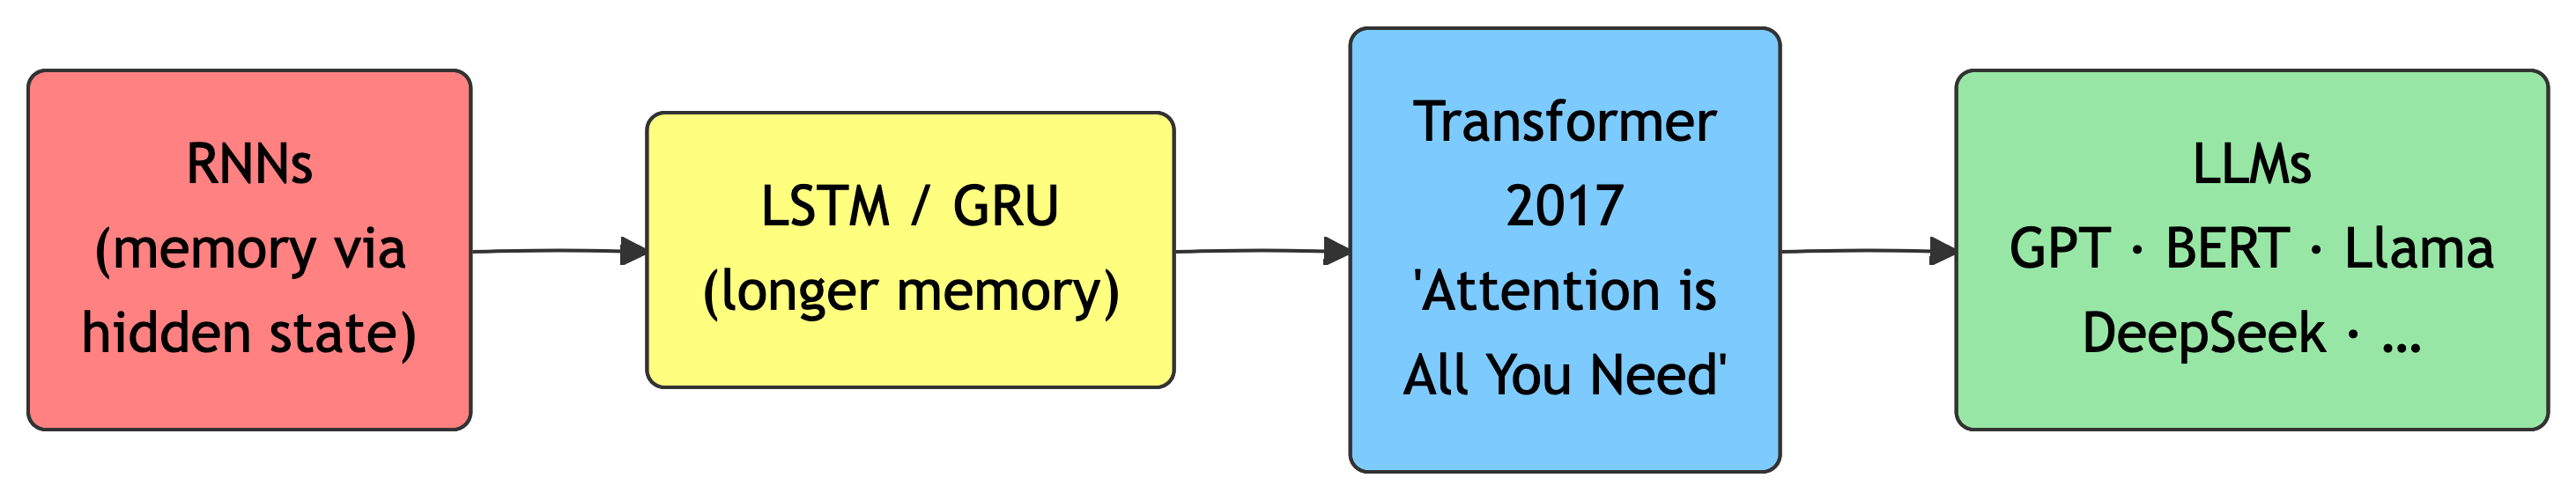
<figcaption>Figure 5: The road to modern LLMs.</figcaption>
</figure>

### Recurrent Neural Networks (RNNs)

RNNs were the traditional tool for temporal dependencies. The hidden
state from the previous step is fed back into the network, giving it a
“memory” of past inputs — ideal for short sequences in NLP and
time-series prediction.

<figure id="fig-rnn">
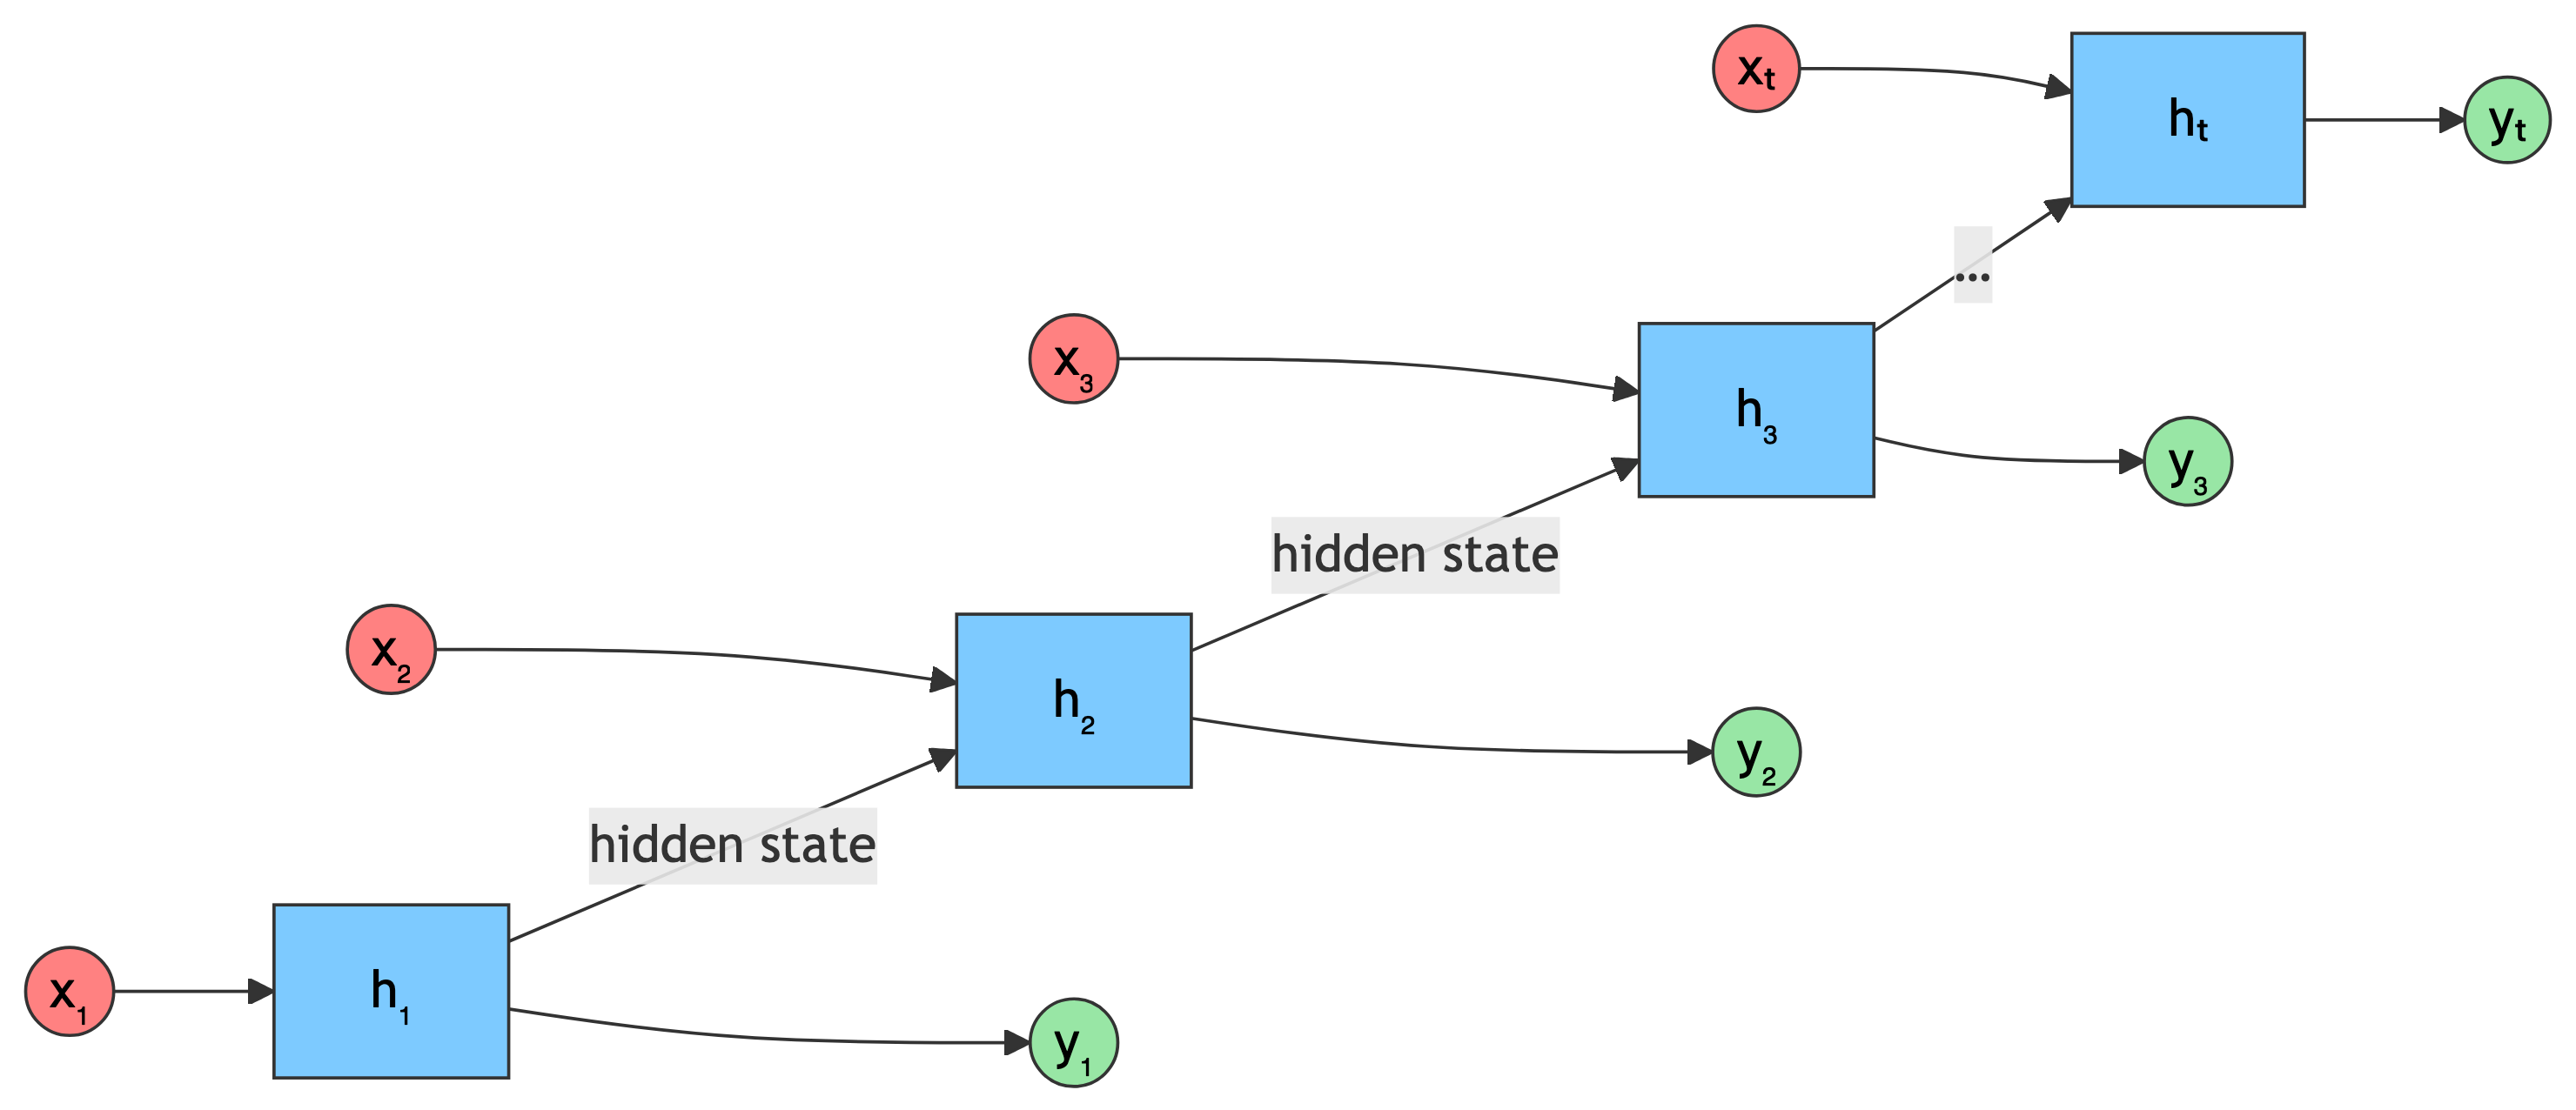
<figcaption>Figure 6: An RNN unrolled over time: the hidden state <span
class="math inline"><em>h</em><sub><em>t</em></sub></span> is passed
from each step to the next, giving the network a “memory” of past
inputs.</figcaption>
</figure>

But RNNs have two crippling limitations:

- **Slow to train.** Each step depends on the previous hidden state, so
  computation is inherently **sequential** — it can’t be parallelized
  across the sequence.
- **Poor with long sequences.** Vanishing/exploding gradients limit how
  far back an RNN can “see.” LSTMs and GRUs mitigate this but don’t
  fully solve it.

### Transformers

The 2017 paper [*Attention Is All You
Need*](https://arxiv.org/abs/1706.03762) replaced recurrence with the
**attention mechanism**, which processes all positions **in parallel**
and directly models long-range dependencies. This unlocked the scale
that defines today’s “large” language models.

Since 2017 the field has moved fast. A rough chronology of landmark
models:

<figure id="fig-transformers-chrono">
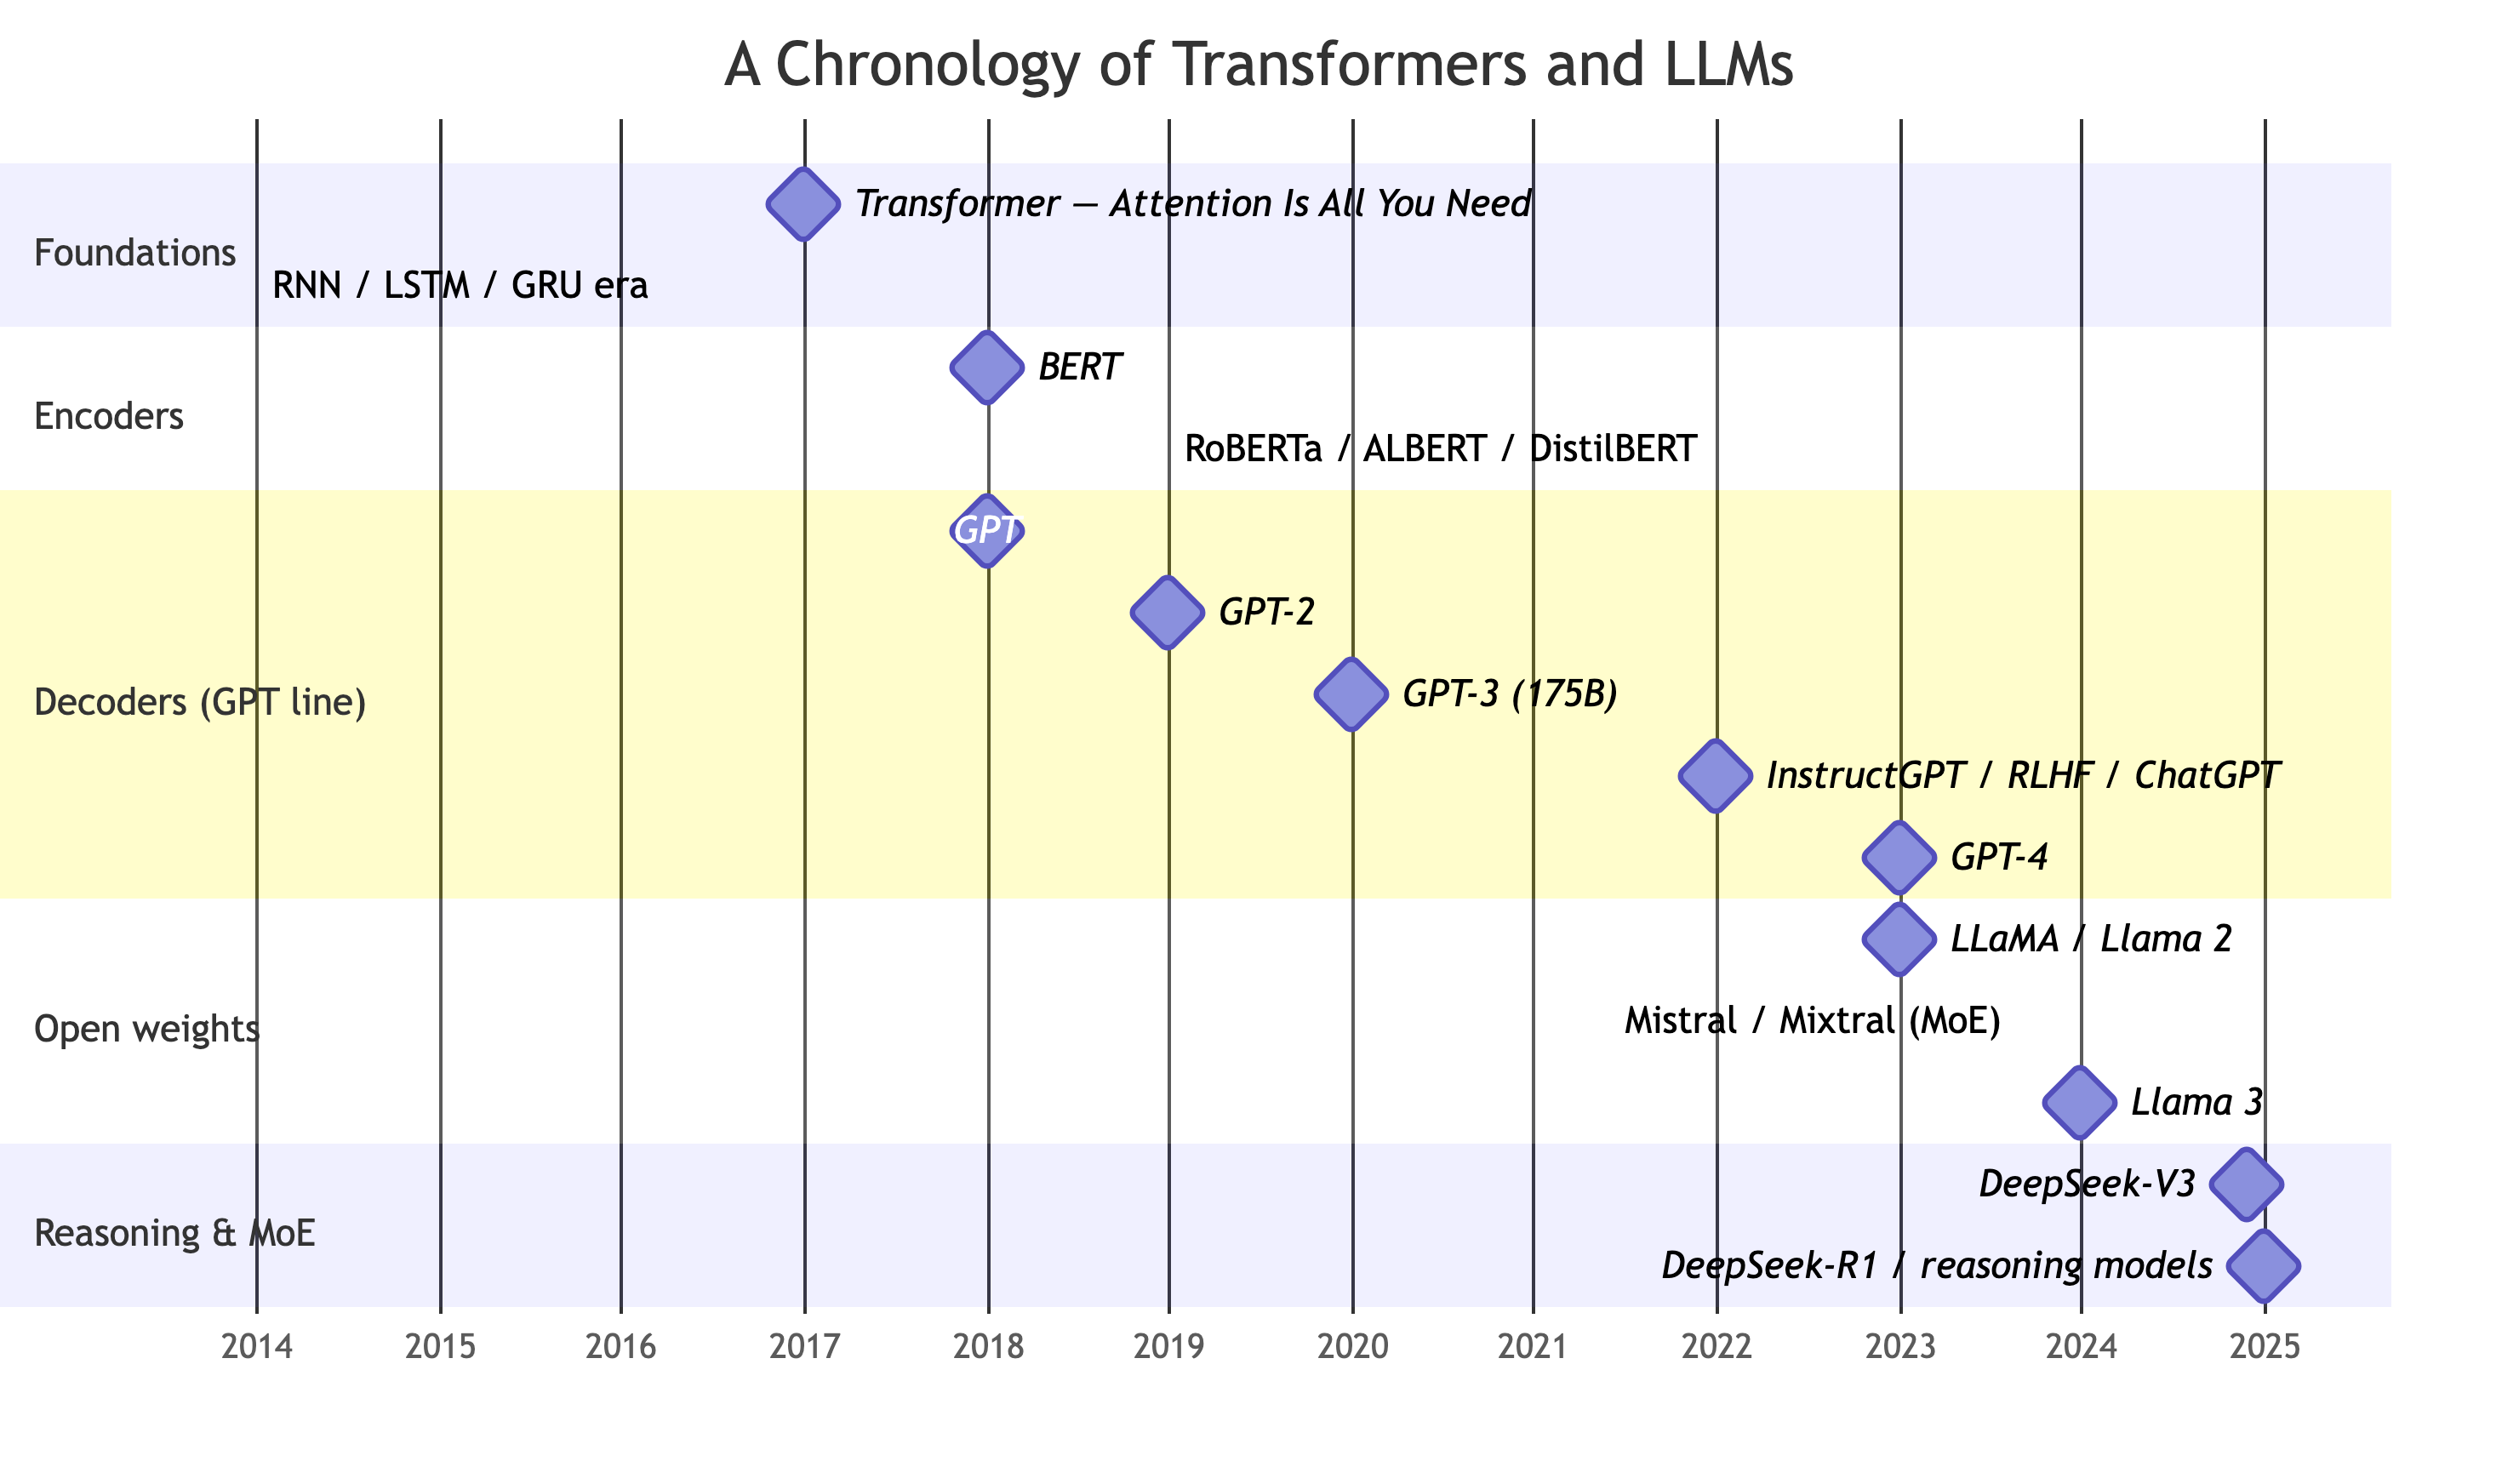
<figcaption>Figure 7: A (non-exhaustive) timeline of landmark
Transformer models. From a single 2017 architecture to today’s frontier
reasoning and Mixture-of-Experts systems.</figcaption>
</figure>

<figure id="fig-transformer-arch">
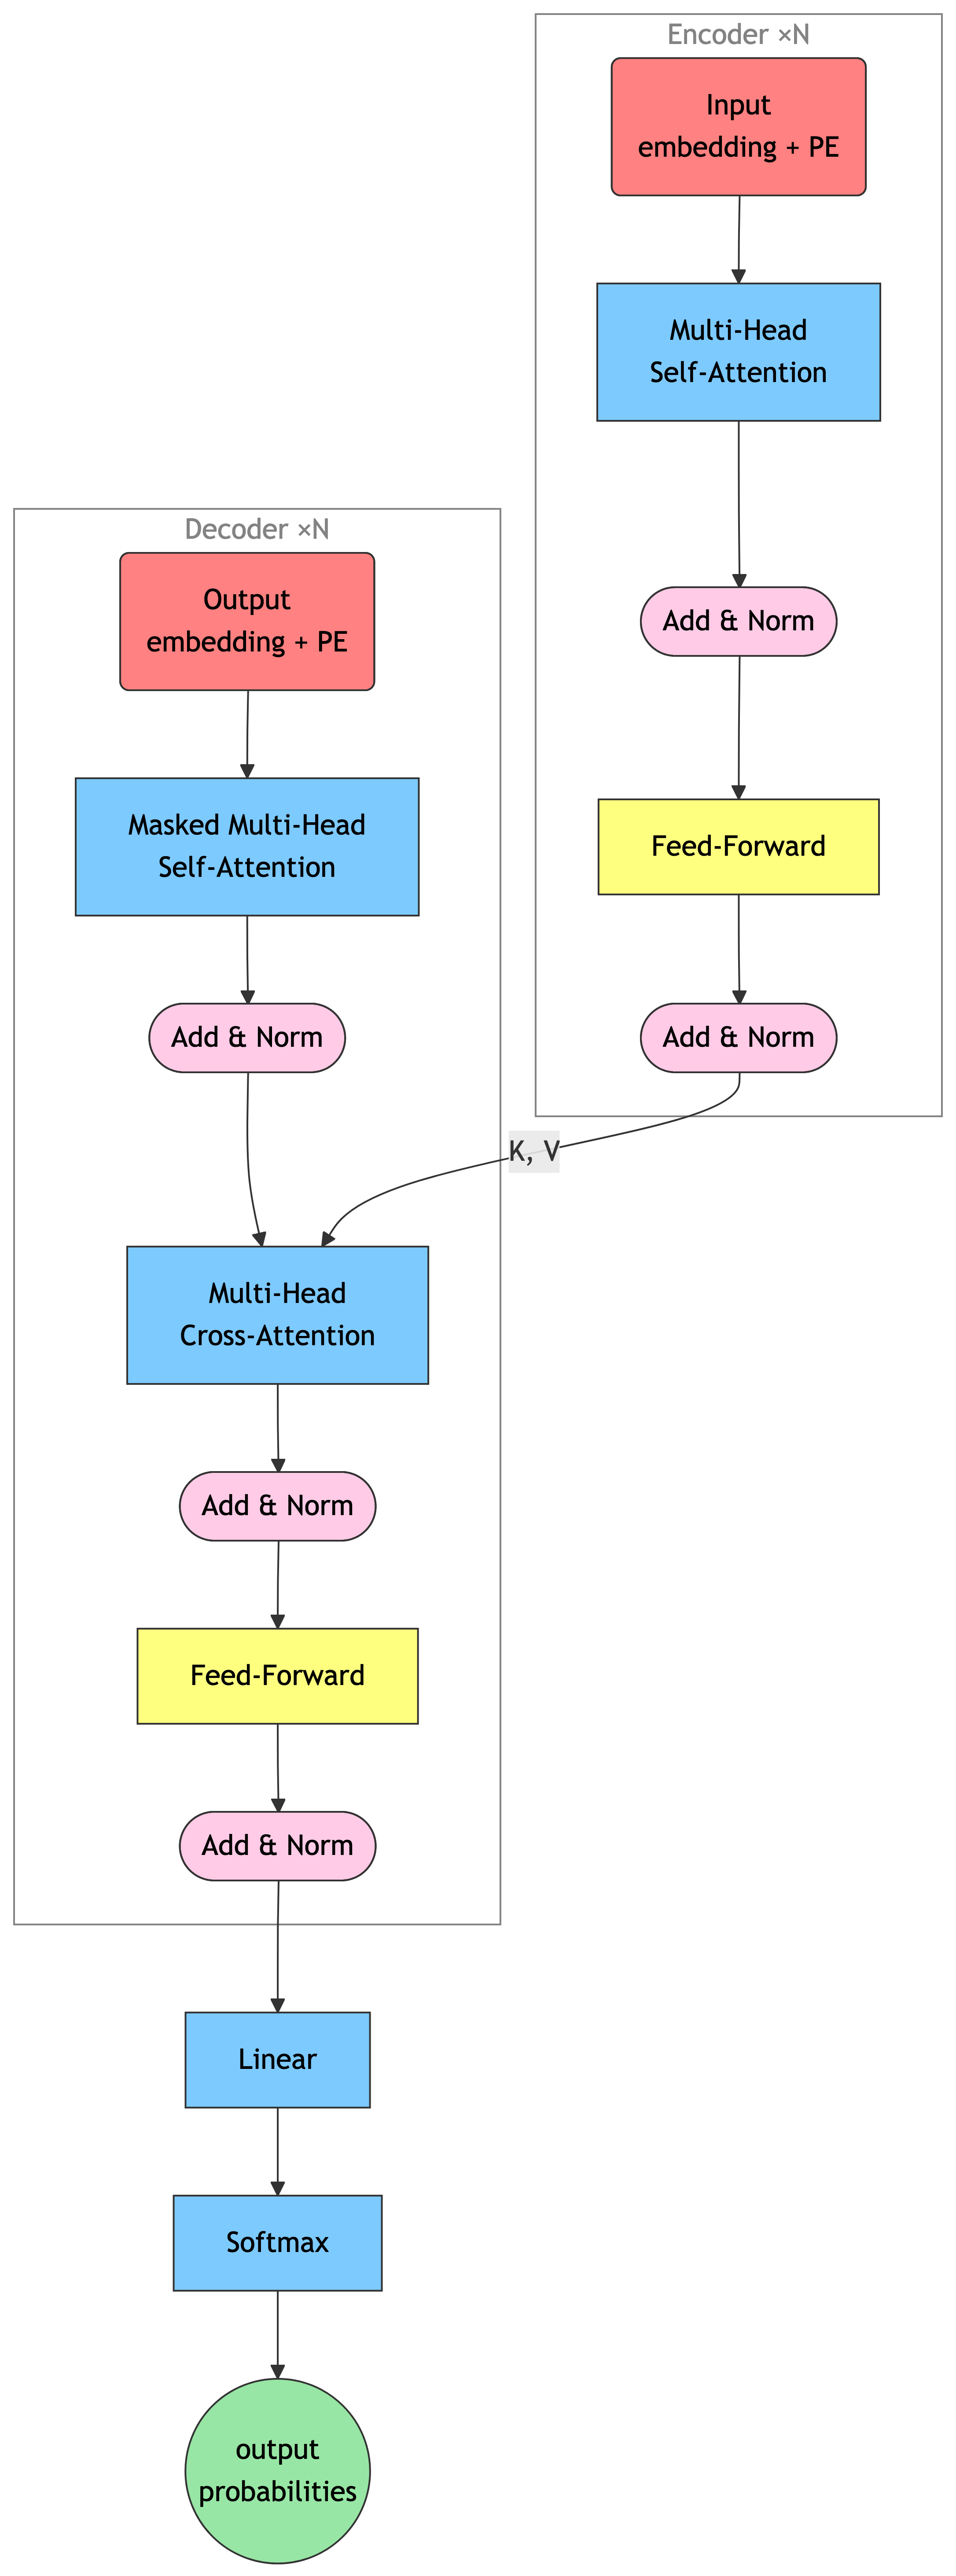
<figcaption>Figure 8: The full encoder–decoder Transformer architecture
(Vaswani et al., 2017): a stack of <code>N</code> encoder layers (left)
whose keys and values feed cross-attention in a stack of <code>N</code>
decoder layers (right), ending in a linear + softmax projection to
output probabilities.</figcaption>
</figure>

## ⚡ LLMs in Action: The Black Box First

Before we open it up, let’s *use* an LLM. We’ll rely on [🤗
`transformers`](https://huggingface.co/docs/transformers), which
packages pretrained models, tokenizers, and pipelines.

> **⚠️ A note on generated content**
>
> LLMs are only as good as their training data. The pretrained models we
> use were trained on wide samples of internet text that were **not**
> strictly filtered, so generated output may occasionally be dark,
> biased, or nonsensical. It does not reflect our values and is shown
> for demonstration only.

In [1]:
# One-time setup (Colab / fresh env). Skip if these are already installed.
%pip install transformers torch pandas rich \
    umap-learn plotly scikit-learn nltk bertviz

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
# svg for HTML, high-res png for PDF
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina', 'svg', 'png')
import matplotlib as mpl
from rich import print

Generating text is three lines with a `pipeline`:

In [3]:
from transformers import pipeline

input_text = "I got an A+ in my final exam; I am very"
generator = pipeline("text-generation", model="openai-community/gpt2")
print(
    [
        i["generated_text"]
        for i in generator(input_text, max_length=20, num_return_sequences=5)
    ]
)

Device set to use mps:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

[ 
 "I got an A+ in my final exam; I am very happy for it!\n\nWhat kind of career would you prefer to take? I think 
 I would like to live in a pretty beautiful European city, but I don't think that would be my ideal life.\n\nI think 
 that I would like to live in a pretty beautiful European city, but I don't think that would be my ideal life. The 
 job market is so bad, you can't find good people in the United States. The best jobs in Asia are in the American 
 market, but you can't find good people in China or South Korea…you have to have people who are more educated than 
 you are. In my experience, the best job in America is in Asia.\n\nMy experience with entrepreneurship has been 
 fascinating, and I think it will lead to a lot of great things and a lot of great people.\n\nI think that it is not 
 about how many people you have. It is about how many people you have to have. Do you see an opportunity to work in 
 China?\n\nI don't think that I would be interested in working in China if I didn't have the opportunity to do the 
 things I am doing. I think that I would be more interested in doing something else.\n\nSo you've got your own 
 company" ,
 'I got an A+ in my final exam; I am very proud of it. But, you know, this is a test of human nature. If you are 
 going to get a good grade, you must have a very good sense of yourself. You must be able to communicate well. That, 
 of course, is not a bad thing. But it is not a very good thing to have a good sense of yourself.\n\nBruno is the 
 creator of the show "The Big Bang Theory" and also co-host for "The X Factor" and will be answering questions from 
 viewers in all 50 states.\n\nWatch the first video of Bruno\'s interview 
 below.\n\n[youtube]http://www.youtube.com/watch?v=1MqZ3wwcK3I[/youtube]\n\nFollow us on Twitter: @bruno_s_\n\nMORE: 
 How to Get An A+ in Life' ,
 'I got an A+ in my final exam; I am very proud of my record. I am glad I went to school for this and I hope 
 I\'ll be able to do this again."\n\nHe said he will do a full online survey of his students to ensure his grade 
 level is correct.\n\n"I really hope to be in the top 5 next year, I would really appreciate it if you would follow 
 me on twitter, I want to see if I can offer you the best, I want to see if you\'ll be able to answer any questions 
 you might have," he said.\n\nThis is the second time the school has been accused of bullying a student over his 
 race.\n\nThe second allegation came to light in October, when a 12-year-old pupil was bullied by a 17-year-old 
 pupil in the school by claiming he had a "big fat butt".\n\nThe school said that the students had been in the 
 classroom during the incident and that it would not tolerate bullying.\n\nAt the time, the school was asking for a 
 full-scale investigation into the incident.' ,
 'I got an A+ in my final exam; I am very impressed."\n\nThe top 10.1% in their field are all from India, and 
 the top 10% are all from India.\n\nThe total number of students, students with B-level diplomas, and students who 
 are over four years old are also lower than those who are under three years old.\n\nThe number of students with 
 B-level diplomas is also lower than those with a B-level diploma.\n\nAnd the number of students who were taught in 
 English or Hindi is even lower than those who were taught in English or Hindi.\n\nBut this is not all.\n\nThe 
 number of students with a B-level certificate is also lower than the number of students with a B-level 
 diploma.\n\nSimilarly, there are significant differences in the number of students with a B-level certificate 
 compared with those without a B-level diploma.\n\nFor example, the number of students with a B-level certificate 
 has a higher average score than the number of students without a B-level certificate.\n\nNot all students with a 
 B-level certificate are able to pass in English.\n\nIn one case, a student who is on his or her B-level diploma and 
 is unable to pass in English was able' ,
 'I g

That’s the whole black box: **text in, text out**. The rest of this
session is about what happens *inside*.

## 🔬 Opening the Black Box

Two components turn a prompt into generated text:

<figure id="fig-blackbox">
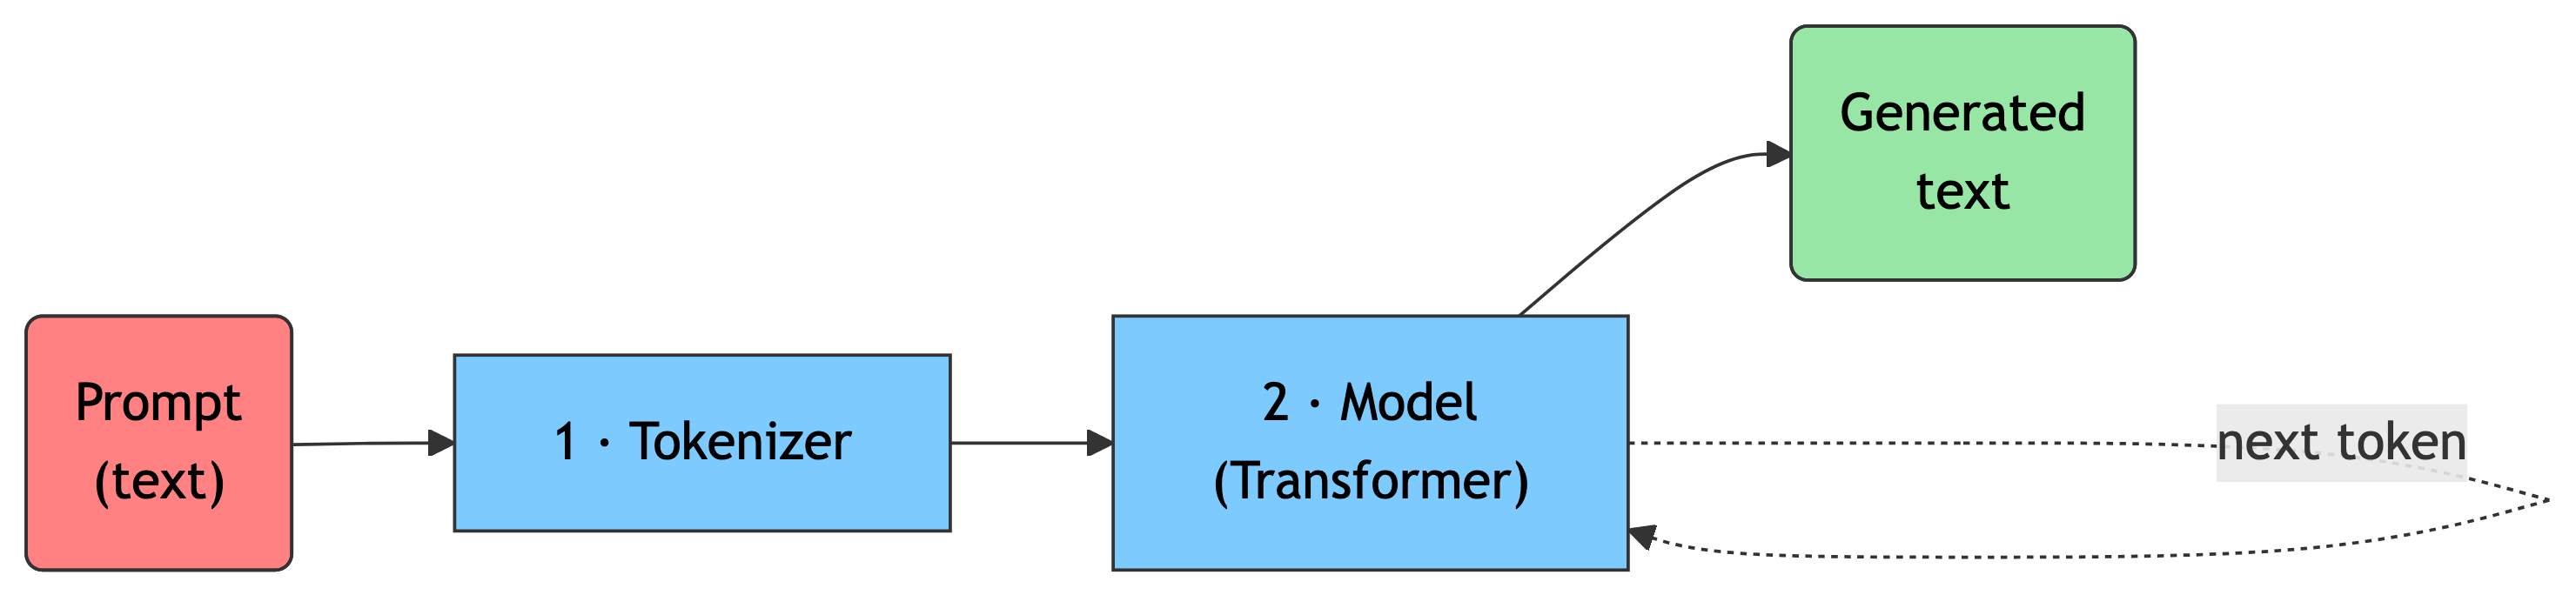
<figcaption>Figure 9: The two black boxes: a <strong>tokenizer</strong>
and the <strong>model</strong> itself.</figcaption>
</figure>

### 1 · Tokenization

Computers operate on numbers, not characters. **Tokenization** splits
text into units (tokens) and maps each to an integer ID.

<figure id="fig-tokenization-pipeline">
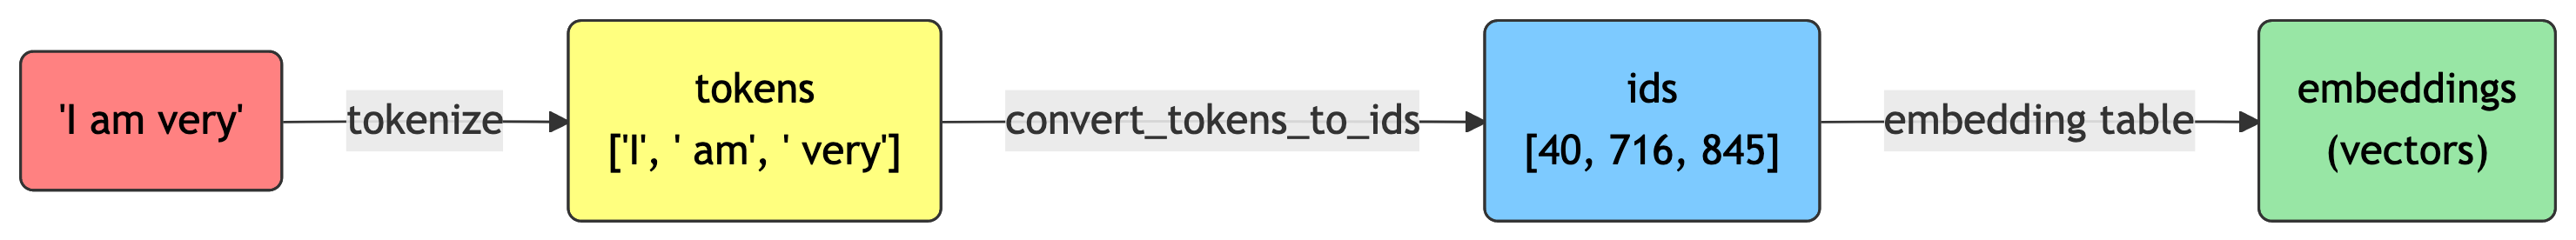
<figcaption>Figure 10: From raw text to model-ready
vectors.</figcaption>
</figure>

GPT-2 uses **Byte-Pair Encoding (BPE)**, a subword scheme that balances
vocabulary size against sequence length. Let’s inspect a tokenizer:

In [4]:
from transformers import AutoTokenizer


def tokenization_summary(tokenizer, sequence):
    # Peek at a slice of the vocabulary
    print("Subset of tokenizer.vocab:")
    for i, (token, index) in enumerate(tokenizer.vocab.items()):
        print(f"{token}: {index}")
        if i >= 9:
            break

    print("Vocab size of the tokenizer =", len(tokenizer.vocab))
    print("------------------------------------------")

    # .tokenize -> subword tokens
    tokens = tokenizer.tokenize(sequence)
    print("Tokens :", tokens)
    print("------------------------------------------")

    # .encode -> integer ids (adds special tokens where applicable)
    print("tokenized sequence :", tokenizer.encode(sequence))

    # .decode -> back to text
    ids = tokenizer.convert_tokens_to_ids(tokens)
    print("Decode sequence :", tokenizer.decode(ids))


tokenizer_1 = AutoTokenizer.from_pretrained("gpt2")  # Byte-Pair Encoding (BPE)
sequence = "I got an A+ in my final exam; I am very"
tokenization_summary(tokenizer_1, sequence)

Subset of tokenizer.vocab:

ĠPadres: 40188

ĠStart: 7253

ĠDew: 25075

ÅĤ: 41615

...

------------------------------------------

Tokens :
 [ 'I' , 'Ġgot' , 'Ġan' , 'ĠA' , '+' , 'Ġin' , 'Ġmy' , 'Ġfinal' , 'Ġexam' , ';' , 'ĠI' , 'Ġam' , 'Ġvery' ]

------------------------------------------

tokenized sequence :
 [ 40 , 1392 , 281 , 317 , 10 , 287 , 616 , 2457 , 2814 , 26 , 314 , 716 , 845 ]

Decode sequence : I got an A+ in my final exam; I am very

### 2 · Token Embeddings

Each token ID is mapped to a vector in a moderate-dimensional space. The
key idea: **similar or related tokens land near each other**, and the
model can *learn* this geometry during training.

The embedding dimension is high (e.g. 768–1024) but much smaller than
the vocabulary (30k–500k). Unlike static word vectors, Transformers
**adjust their embeddings during training**.

We can *see* this structure by projecting BERT embeddings down to 3-D
with PCA:

In [5]:
import nltk
import numpy as np
import pandas as pd
import plotly.express as px
from nltk.corpus import stopwords
from sklearn.decomposition import PCA
from transformers import BertModel, BertTokenizer

nltk.download("stopwords")
import torch

model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

text = (
    "The diligent student diligently studied hard for his upcoming exams "
    "He was incredibly conscientious in his efforts and committed himself "
    "to mastering every subject"
)

# Tokenize and get BERT embeddings
tokens = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
with torch.no_grad():
    outputs = model(**tokens)
    embeddings = outputs.last_hidden_state.squeeze(0).numpy()  # (num_tokens, 768)

# Labels without special/subword tokens
labels = [tokenizer.convert_ids_to_tokens(i) for i in tokens.input_ids[0].tolist()]
filtered_labels = [
    label
    for label in labels
    if not (label.startswith("[") and label.endswith("]")) and "##" not in label
]

# Drop stopwords
stop_words = set(stopwords.words("english"))
filtered_labels = [l for l in filtered_labels if l.lower() not in stop_words]
filtered_embeddings = embeddings[: len(filtered_labels)]

# PCA -> 3-D
embeddings_pca = PCA(n_components=3).fit_transform(filtered_embeddings)
df_pca = pd.DataFrame(
    {
        "x": embeddings_pca[:, 0],
        "y": embeddings_pca[:, 1],
        "z": embeddings_pca[:, 2],
        "label": filtered_labels,
    }
)

fig_pca = px.scatter_3d(
    df_pca, x="x", y="y", z="z", text="label",
    title="PCA 3-D Visualization of Token Embeddings",
    labels={"x": "Dim 1", "y": "Dim 2", "z": "Dim 3"},
    hover_name="label",
)
fig_pca.update_traces(marker=dict(size=5), textfont=dict(size=8))
fig_pca.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/samforeman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!

You should see semantically related words cluster together!

## 🧱 Inside a Transformer

Now the model itself. We’ll dissect **GPT-2**, a *Transformer decoder*
used to generate text. Let’s look at its structure:

In [6]:
from transformers import GPT2LMHeadModel

model = GPT2LMHeadModel.from_pretrained("gpt2")
print(model)

GPT2LMHeadModel ( 
 ( transformer ) : GPT2Model ( 
 ( wte ) : Embedding ( 50257 , 768 ) 
 ( wpe ) : Embedding ( 1024 , 768 ) 
 ( drop ) : Dropout ( p = 0.1 , inplace = False ) 
 ( h ) : ModuleList ( 
 ( 0 - 11 ) : 12 x GPT2Block ( 
 ( ln_1 ) : LayerNorm (( 768 , ) , eps = 1e-05 , elementwise_affine = True ) 
 ( attn ) : GPT2Attention ( 
 ( c_attn ) : Conv1D ( nf = 2304 , nx = 768 ) 
 ( c_proj ) : Conv1D ( nf = 768 , nx = 768 ) 
 ( attn_dropout ) : Dropout ( p = 0.1 , inplace = False ) 
 ( resid_dropout ) : Dropout ( p = 0.1 , inplace = False ) 
 ) 
 ( ln_2 ) : LayerNorm (( 768 , ) , eps = 1e-05 , elementwise_affine = True ) 
 ( mlp ) : GPT2MLP ( 
 ( c_fc ) : Conv1D ( nf = 3072 , nx = 768 ) 
 ( c_proj ) : Conv1D ( nf = 768 , nx = 3072 ) 
 ( act ) : NewGELUActivation () 
 ( dropout ) : Dropout ( p = 0.1 , inplace = False ) 
 ) 
 ) 
 ) 
 ( ln_f ) : LayerNorm (( 768 , ) , eps = 1e-05 , elementwise_affine = True ) 
 ) 
 ( lm_head ) : Linear ( in_features = 768 , out_features = 50257 , bias = False ) 
 )

Decoder-only models like GPT are **auto-regressive**: at each step, the
attention layers can only see tokens *before* the current position, and
the model is trained to predict the next token. This makes them ideal
for text generation (GPT, GPT-2, CTRL, Transformer-XL, …).

A Transformer decoder is a stack of identical **blocks**, each with two
sub-layers: **masked self-attention** and a **feed-forward network**,
wrapped in residual connections and layer normalization.

<figure id="fig-decoder-block">
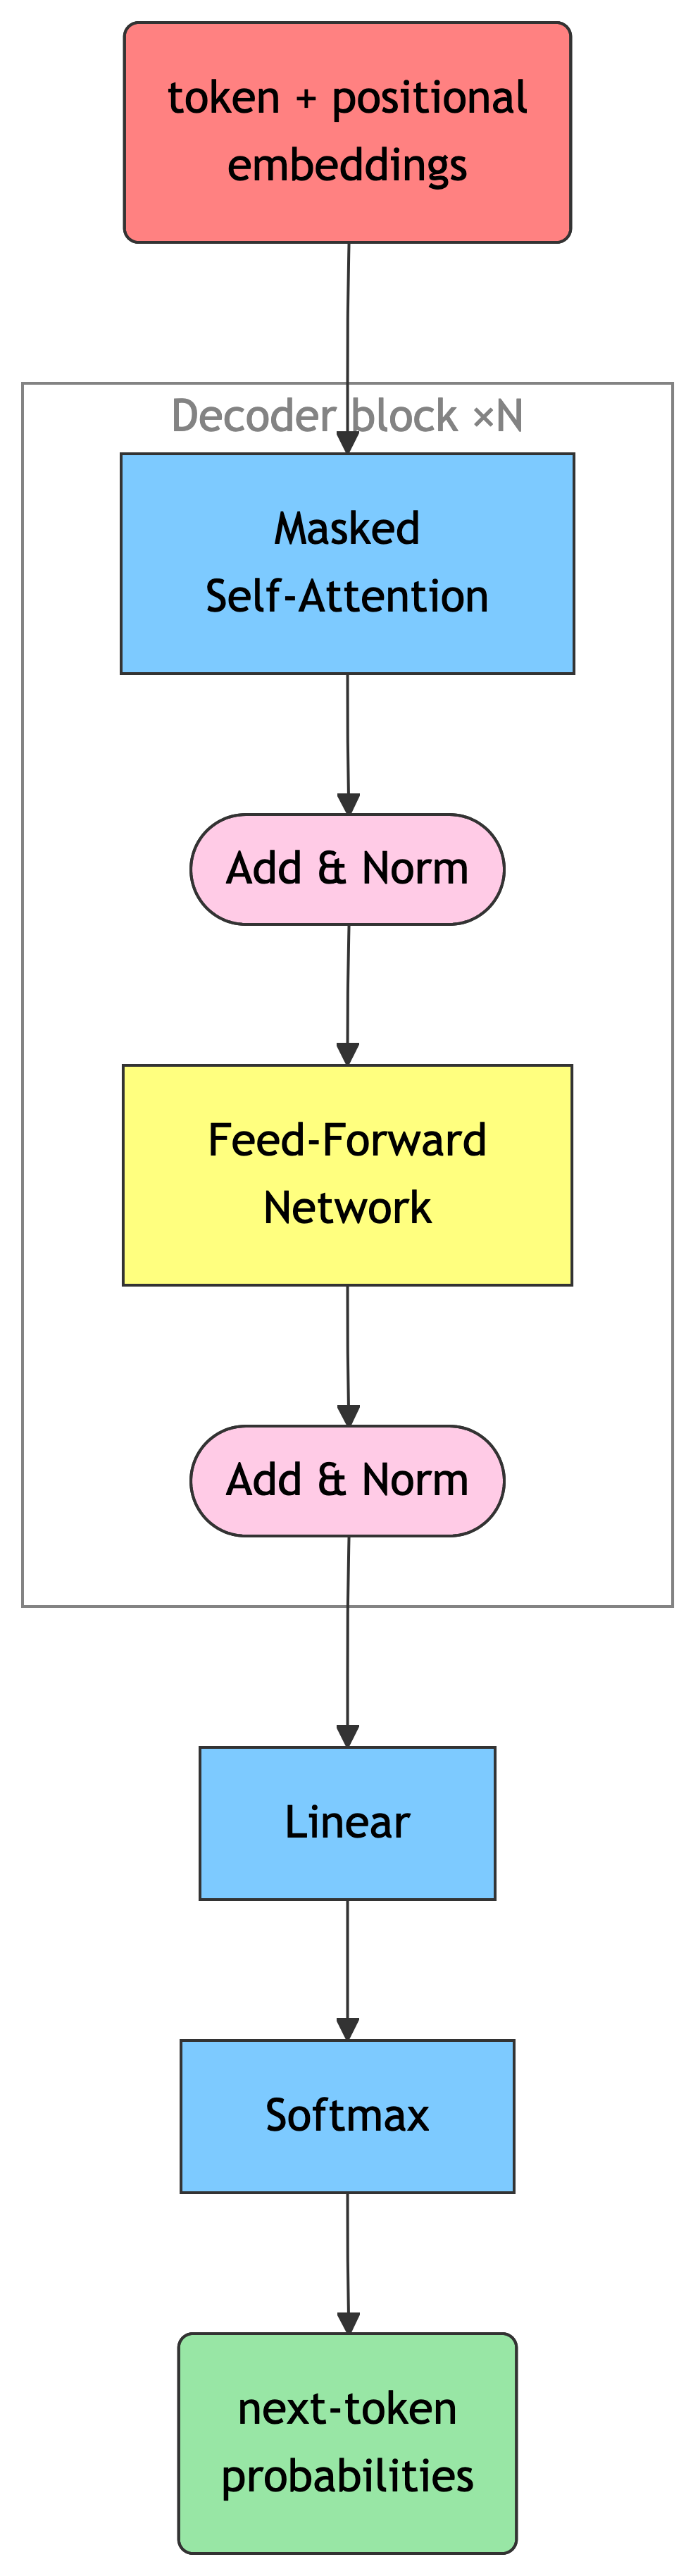
<figcaption>Figure 11: The anatomy of a decoder block. The stack repeats
<code>N</code> times before the final projection to vocabulary
logits.</figcaption>
</figure>

We’ll set some hyperparameters we’ll reuse throughout:

In [7]:
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(1337)

# hyperparameters
batch_size = 16    # independent sequences processed in parallel
block_size = 32    # maximum context length
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = "cuda" if torch.cuda.is_available() else "cpu"
eval_iters = 200
n_embd = 64
n_head = 4         # -> head_size = 16
n_layer = 4
dropout = 0.0

### Attention: the core idea

Consider the sentence:

> “The animal didn’t cross the street because **it** was too tired.”

We intuitively know “it” refers to “animal.” **Self-attention** is how a
Transformer learns these relationships: as it processes each token, it
looks at *other* positions for context.

<figure id="fig-attention-viz">
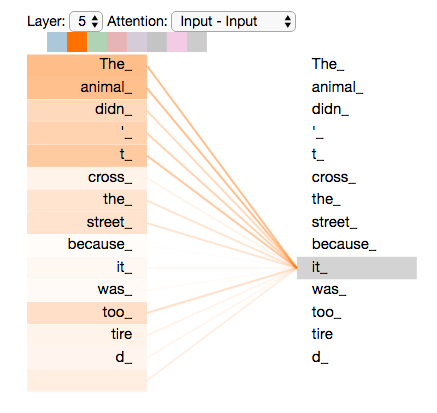
<figcaption>Figure 12: Self-attention relates each word to others in the
sentence. Image credit: <a
href="https://jalammar.github.io/illustrated-transformer/">Jay
Alammar</a>.</figcaption>
</figure>

Attention uses three learned projections of each token:

- **Query (Q)** — what this token is *looking for*
- **Key (K)** — what each token *offers* (matched against queries)
- **Value (V)** — the actual content to aggregate

Jay Alammar’s analogy: picking a file from a cabinet using a sticky
note. The note (query) matches a folder label (key); you then read that
folder’s contents (value), weighted by how well it matched.

<figure id="fig-attention-flow">
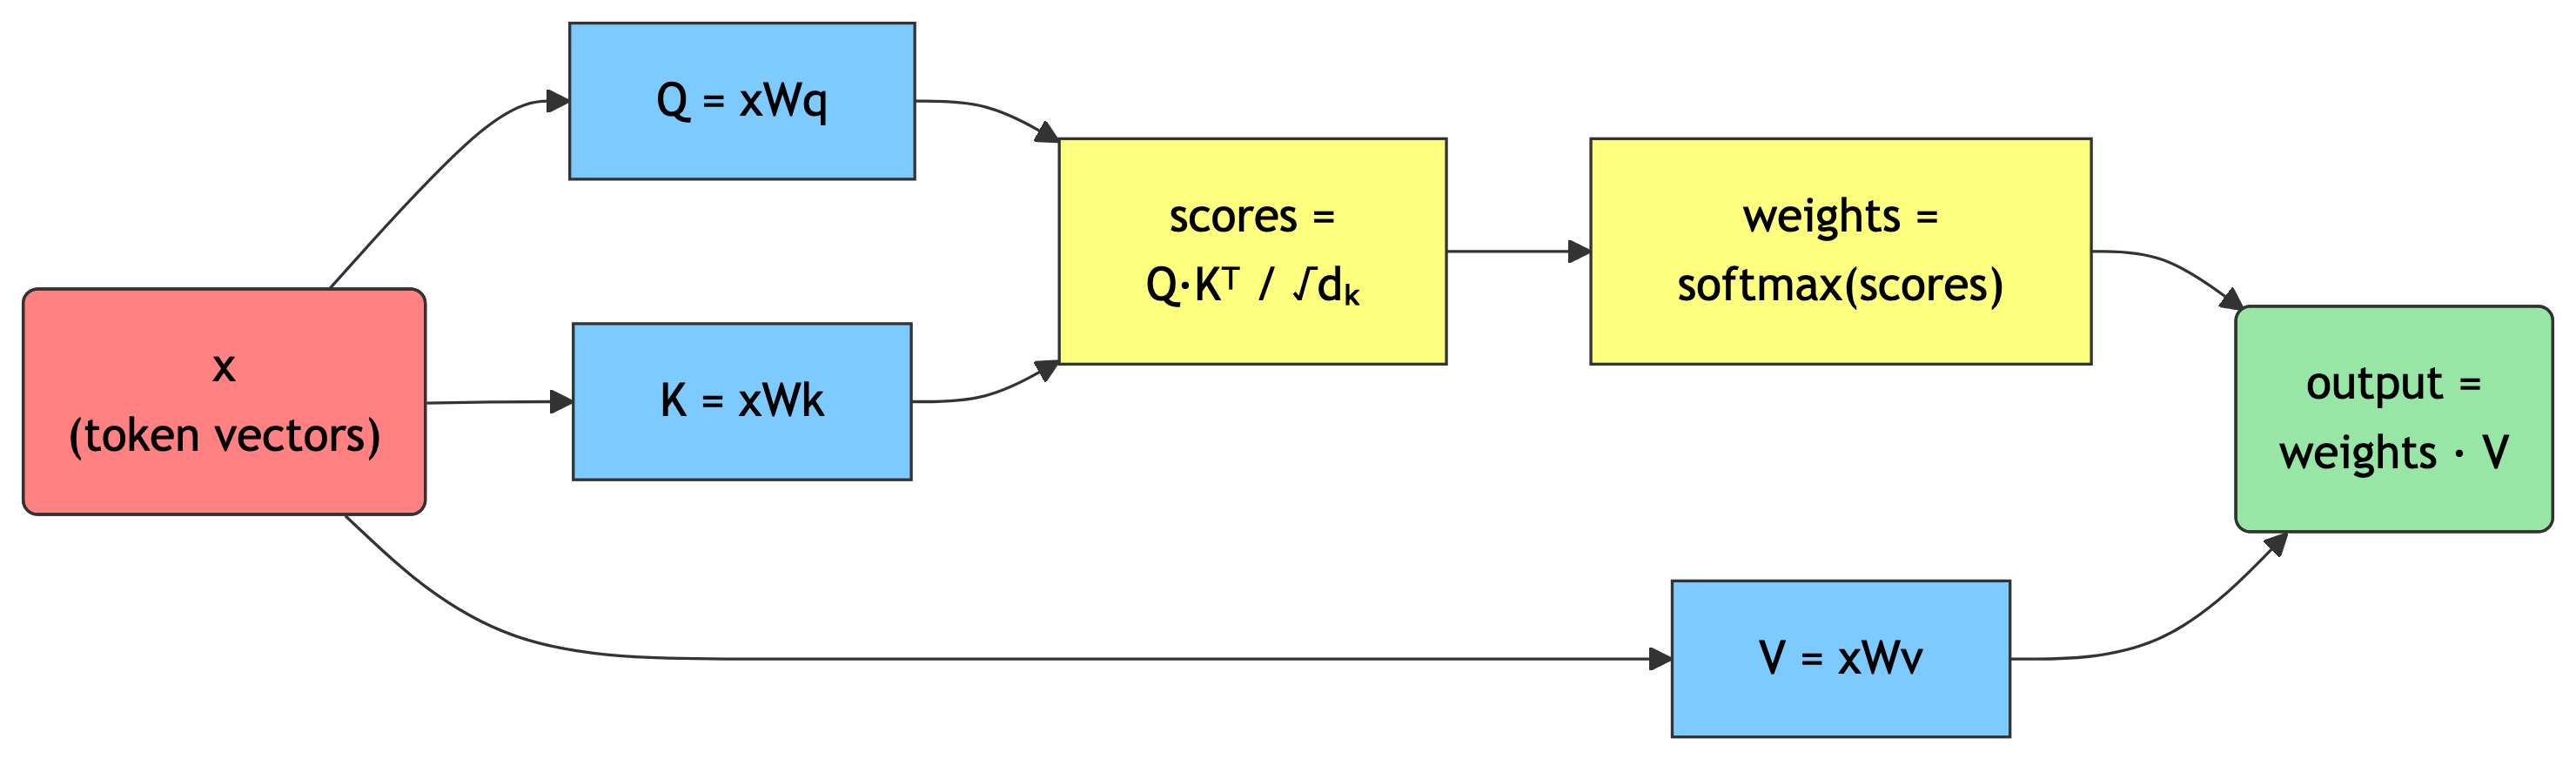
<figcaption>Figure 13: Scaled dot-product attention. The <span
class="math inline">$\sqrt{d_k}$</span> divisor stabilizes gradients
before the softmax.</figcaption>
</figure>

The algorithm in words:

1.  Compute Q, K, V for each token.
2.  Score every token against every other: $\text{scores} = QK^{\top}$.
3.  Scale by $\sqrt{d_k}$ and apply softmax → attention weights.
4.  Weight the value vectors by these weights and sum.

In code:

In [8]:
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(1337)
B, T, C = 4, 8, 32  # batch, time, channels
x = torch.randn(B, T, C)

head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)       # (B, T, 16)
q = query(x)     # (B, T, 16)
v = value(x)     # (B, T, 16)

wei = q @ k.transpose(-2, -1) * head_size**-0.5  # (B, T, T)
wei = F.softmax(wei, dim=-1)                      # normalize -> distribution
out = wei @ v                                     # (B, T, 16)
print(out[0])

tensor ([[ 0.0618 , -0.0091 , -0.3488 , 0.3208 , 0.2971 , -0.1573 , -0.0561 , 0.1068 ,
 0.0368 , 0.0139 , -0.0017 , 0.3110 , 0.1404 , -0.0158 , 0.1853 , 0.4290 ] ,
 [ 0.1578 , -0.0971 , -0.4256 , 0.3538 , 0.3621 , -0.2392 , -0.0536 , 0.1759 ,
 0.1115 , 0.0282 , -0.0649 , 0.3641 , 0.1928 , 0.0261 , 0.2162 , 0.3758 ] ,
 [ 0.1293 , 0.0759 , -0.2946 , 0.2292 , 0.2215 , -0.0710 , -0.0107 , 0.1616 ,
 -0.0930 , -0.0877 , 0.0567 , 0.1899 , 0.0311 , -0.0894 , 0.0309 , 0.5471 ] ,
 [ 0.1247 , 0.1400 , -0.2436 , 0.1819 , 0.1976 , 0.0338 , -0.0028 , 0.1124 ,
 -0.1477 , -0.0748 , 0.0650 , 0.1392 , -0.0314 , -0.0989 , 0.0613 , 0.5433 ] ,
 [ 0.0667 , 0.1845 , -0.2135 , 0.2813 , 0.2064 , 0.0873 , 0.0084 , 0.2055 ,
 -0.1130 , -0.1466 , 0.0459 , 0.1923 , -0.0275 , -0.1107 , 0.0065 , 0.4674 ] ,
 [ 0.1924 , 0.1693 , -0.1568 , 0.2284 , 0.1620 , 0.0737 , 0.0443 , 0.2519 ,
 -0.1912 , -0.1979 , 0.0832 , 0.0713 , -0.0826 , -0.0848 , -0.1047 , 0.6089 ] ,
 [ 0.1184 , 0.0884 , -0.2652 , 0.2560 , 0.1840 , 0.0284 , -0.0621 , 0.1181 ,
 -0.0880 , 0.0104 , 0.1123 , 0.1850 , 0.0369 , -0.0730 , 0.0663 , 0.5242 ] ,
 [ 0.1243 , 0.0453 , -0.3412 , 0.2709 , 0.2335 , -0.0948 , -0.0421 , 0.2143 ,
 -0.0330 , -0.0313 , 0.0520 , 0.2378 , 0.1084 , -0.0959 , 0.0300 , 0.4707 ]] ,
 grad_fn = < SelectBackward0 >)

### Multi-head attention

In practice we run several attention “heads” in parallel. Each head can
focus on a different kind of relationship (syntax, coreference, …), and
their outputs are concatenated. This gives the model multiple
**representation subspaces**.

<figure id="fig-multihead">
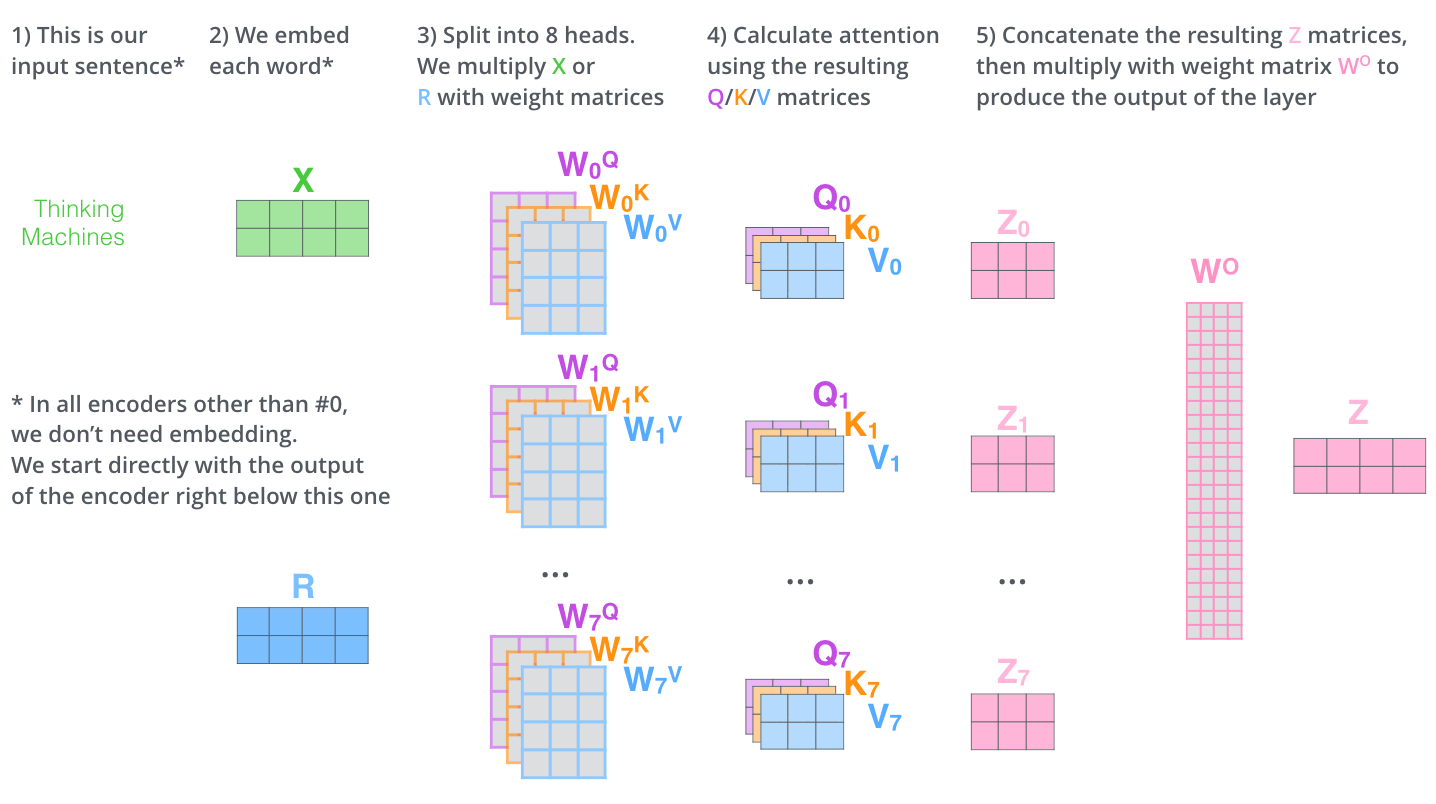
<figcaption>Figure 14: Multi-head attention. Image credit: <a
href="https://jalammar.github.io/illustrated-transformer/">Jay
Alammar</a>.</figcaption>
</figure>

### Attention, visualized interactively

[`bertviz`](https://github.com/jessevig/bertviz) lets us inspect real
attention weights. **Click the different colored blocks** to see which
tokens attend to which.

In [9]:
from bertviz import model_view
from transformers import AutoModelForCausalLM, AutoTokenizer, utils

utils.logging.set_verbosity_error()  # suppress standard warnings

model_name = "openai-community/gpt2"
input_text = "The animal didn't cross the street because it was too tired"
model = AutoModelForCausalLM.from_pretrained(model_name, output_attentions=True)
tokenizer = AutoTokenizer.from_pretrained(model_name)

inputs = tokenizer.encode(input_text, return_tensors="pt")
outputs = model(inputs)
attention = outputs[-1]
tokens = tokenizer.convert_ids_to_tokens(inputs[0])
model_view(attention, tokens)

### Positional encoding

Attention alone is **order-blind** — it sees a *set* of tokens, not a
sequence. But order matters enormously:

> “The man ate the sandwich.” vs. “The sandwich ate the man.”

Same words, very different meaning. Transformers restore order by
**adding a positional encoding** vector to each token embedding.

<figure id="fig-positional-encoding">
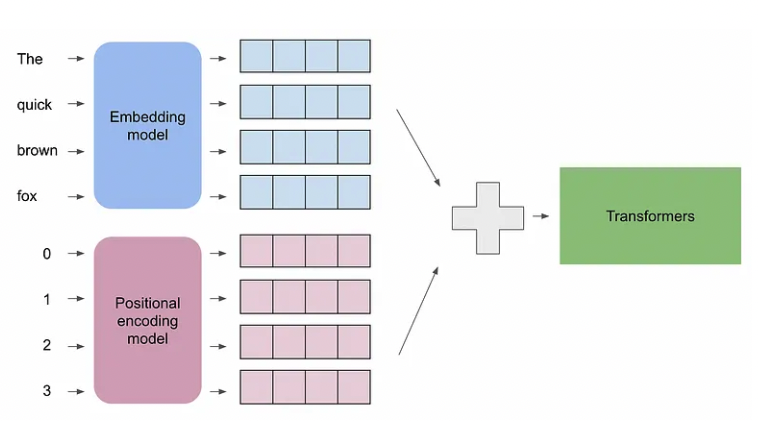
<figcaption>Figure 15: Positional encodings are added to token
embeddings. Image credit: <a
href="https://medium.com/@xuer.chen.human/llm-study-notes-positional-encoding-0639a1002ec0">Chen</a>.</figcaption>
</figure>

We can implement a (learned) positional embedding with `nn.Embedding`,
sized `(block_size, n_embd)` — one vector per position:

In [10]:
vocab_size = 65
n_embd = 64
block_size = 32

token_embedding_table = nn.Embedding(vocab_size, n_embd)
position_embedding_table = nn.Embedding(block_size, n_embd)

Token embedding alone:

In [11]:
x = torch.tensor([1, 3, 15, 4, 7, 1, 4, 9])
print(token_embedding_table(x)[0])

tensor ([ 0.7221 , -0.9629 , -2.0578 , 1.9740 , 0.7434 , 1.1139 , 0.6926 , 0.0296 ,
 0.6405 , -1.6464 , 0.4935 , 0.7485 , 0.9238 , -0.4940 , 0.4814 , -0.3859 ,
 -0.3094 , 1.1066 , -0.2891 , 0.1891 , 2.0440 , -0.7945 , -0.4331 , 0.3007 ,
 1.4317 , 0.2881 , -0.4343 , 0.4280 , 1.2469 , 1.4047 , -0.3404 , -2.2190 ,
 0.4893 , 0.0398 , -0.2717 , -2.2400 , -0.0029 , -1.4251 , 0.7330 , 0.3551 ,
 0.1472 , -1.1895 , -0.8407 , 0.3134 , -0.6709 , -0.8176 , 0.6929 , -0.6374 ,
 0.3174 , 0.4837 , -0.0073 , -1.5924 , 1.8606 , -1.2910 , -0.1594 , 0.3111 ,
 -0.1536 , -0.3414 , -0.0170 , -0.1633 , 0.2794 , 0.6755 , 0.7066 , -1.6665 ] ,
 grad_fn = < SelectBackward0 >)

Token **+** positional embedding (note the offset):

In [12]:
x = torch.tensor([1, 3, 15, 4, 7, 1, 4, 9])
print((position_embedding_table(x) + token_embedding_table(x))[0])

tensor ([ 0.4326 , -1.6287 , -0.8684 , 3.0704 , 0.3646 , 1.9826 , 0.7582 , -0.1918 ,
 1.0491 , -2.2562 , -0.4931 , -0.7808 , 1.7206 , -1.0297 , 2.0798 , -1.3427 ,
 -0.7896 , -0.1746 , 0.0926 , 0.0543 , 2.3831 , -0.6208 , 0.3902 , 0.1097 ,
 1.0455 , -1.4557 , 0.3402 , 2.6717 , 1.8380 , 1.2628 , -0.4831 , -4.6023 ,
 0.6959 , 1.0347 , 0.5903 , -0.7541 , 0.4682 , -0.3895 , 2.1526 , 0.6272 ,
 -0.8558 , -0.8434 , 0.1311 , -1.0272 , -2.0580 , 0.0584 , 0.3442 , -0.3464 ,
 -0.3444 , 2.3134 , -1.1142 , -1.4629 , 3.3503 , -2.0594 , 1.4105 , 0.4558 ,
 -1.3366 , 1.9283 , 1.5187 , 0.3906 , 1.1448 , -0.8422 , 2.2692 , -0.7949 ] ,
 grad_fn = < SelectBackward0 >)

Both are learned during training to best encode content *and* position.

### Output layer: from vectors back to words

After the decoder stack, each position holds a vector. A final
**Linear** layer projects it to a **logits** vector — one score per
vocabulary entry — and **softmax** turns those scores into
probabilities. The highest-probability token (or a sample from the
distribution) becomes the output.

<figure id="fig-output-softmax">
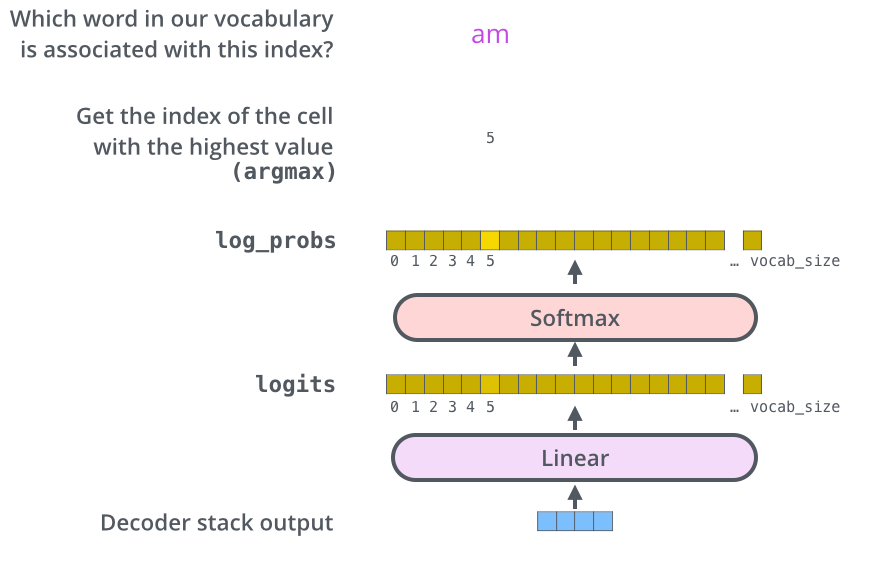
<figcaption>Figure 16: Linear + softmax turn the final vector into a
next-token distribution. Image credit: <a
href="https://jalammar.github.io/illustrated-transformer/">Jay
Alammar</a>.</figcaption>
</figure>

## 🎯 Training a Language Model

How does the model improve? We compare its predicted next-token
distribution to the ground truth and minimize the difference.

<figure id="fig-training-loop">
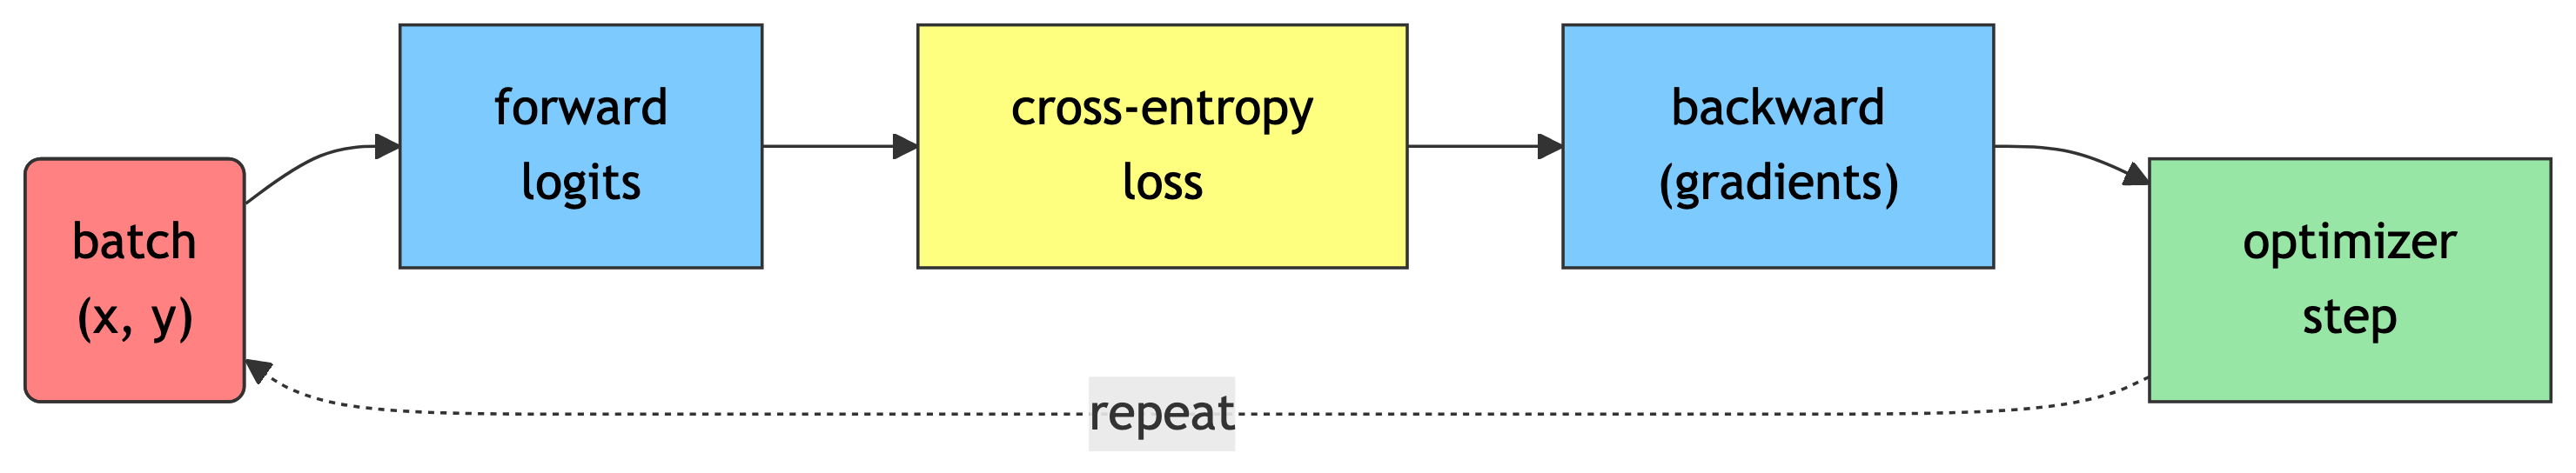
<figcaption>Figure 17: The training loop: predict → score → update,
repeated over many batches.</figcaption>
</figure>

The standard loss is **cross-entropy** between the true distribution $p$
and the predicted distribution $q$:

$$\mathrm{CE} = -\sum_{x \in X} p(x)\, \log q(x)$$

In [13]:
from torch.nn import functional as F

logits = torch.tensor([0.5, 0.1, 0.3])
targets = torch.tensor([1.0, 0.0, 0.0])
loss = F.cross_entropy(logits, targets)
print(loss)

tensor ( 0.9119 )

A closely related, more interpretable metric is **perplexity** —
intuitively, “how surprised” the model is by new data. Lower is better.
It’s just the exponential of the cross-entropy:

$$\text{perplexity} = \exp(\mathrm{CE})$$

In [14]:
print(torch.exp(loss))

tensor ( 2.4891 )

## 🛠️ Build a Mini-LLM from Scratch

Time to assemble everything into a small, working GPT-style model,
trained on the tiny-Shakespeare dataset with a character-level
tokenizer.

### Hyperparameters

In [15]:
batch_size = 4     # independent sequences in parallel
block_size = 32    # maximum context length
max_iters = 500
eval_interval = 50
learning_rate = 1e-3
device = "cuda" if torch.cuda.is_available() else "cpu"
eval_iters = 200
n_embd = 64
n_head = 4         # head_size = 16
n_layer = 4
dropout = 0.0

### Data: tiny-Shakespeare

We use a simple **character-level** tokenizer and a 90/10 train/val
split.

In [16]:
! [ ! -f "input.txt" ] && wget https://raw.githubusercontent.com/argonne-lcf/ATPESC_MachineLearning/refs/heads/master/02_intro_to_LLMs/dataset/input.txt

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
    - Avoid using `tokenizers` before the fork if possible
    - Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)

In [17]:
with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

# unique characters -> vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]           # string -> list[int]
decode = lambda l: "".join([itos[i] for i in l])  # list[int] -> string

# train / val split
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]


def get_batch(split):
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

In [18]:
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.

### Components: attention head, multi-head, feed-forward

In [19]:
class Head(nn.Module):
    """One head of self-attention."""

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)    # (B, T, C)
        q = self.query(x)  # (B, T, C)
        # attention scores ("affinities")
        wei = q @ k.transpose(-2, -1) * C**-0.5      # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))  # causal mask
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)  # (B, T, C)
        return wei @ v     # (B, T, C)


class MultiHeadAttention(nn.Module):
    """Multiple heads of self-attention in parallel."""

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedFoward(nn.Module):
    """A linear layer followed by a non-linearity."""

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),  # projection back to residual stream
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

### The Transformer block

Each block does **communication** (attention) followed by
**computation** (feed-forward), each with a residual connection and
pre-layer-norm:

In [20]:
class Block(nn.Module):
    """Transformer block: communication followed by computation."""

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))    # communication
        x = x + self.ffwd(self.ln2(x))  # computation
        return x

### The full model

Token embeddings + positional embeddings → a stack of blocks → final
layer-norm → linear head to vocabulary logits:

In [21]:
class LanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(
            *[Block(n_embd, n_head=n_head) for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)                         # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))  # (T,C)
        x = tok_emb + pos_emb          # (B,T,C)
        x = self.blocks(x)             # (B,T,C)
        x = self.ln_f(x)               # (B,T,C)
        logits = self.lm_head(x)       # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]        # crop to context window
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]              # last time step -> (B, C)
            probs = F.softmax(logits, dim=-1)      # (B, C)
            idx_next = torch.multinomial(probs, num_samples=1)  # sample
            idx = torch.cat((idx, idx_next), dim=1)             # append
        return idx

## 🤗 Using Pretrained Models with HuggingFace

Building from scratch teaches you *how* Transformers work. In practice,
you’ll usually start from a **pretrained** model and adapt it. The [🤗
`transformers`](https://huggingface.co/docs/transformers) library makes
this a few lines of code. Let’s walk a complete
**sentiment-classification** pipeline end-to-end.

<figure id="fig-hf-pipeline">
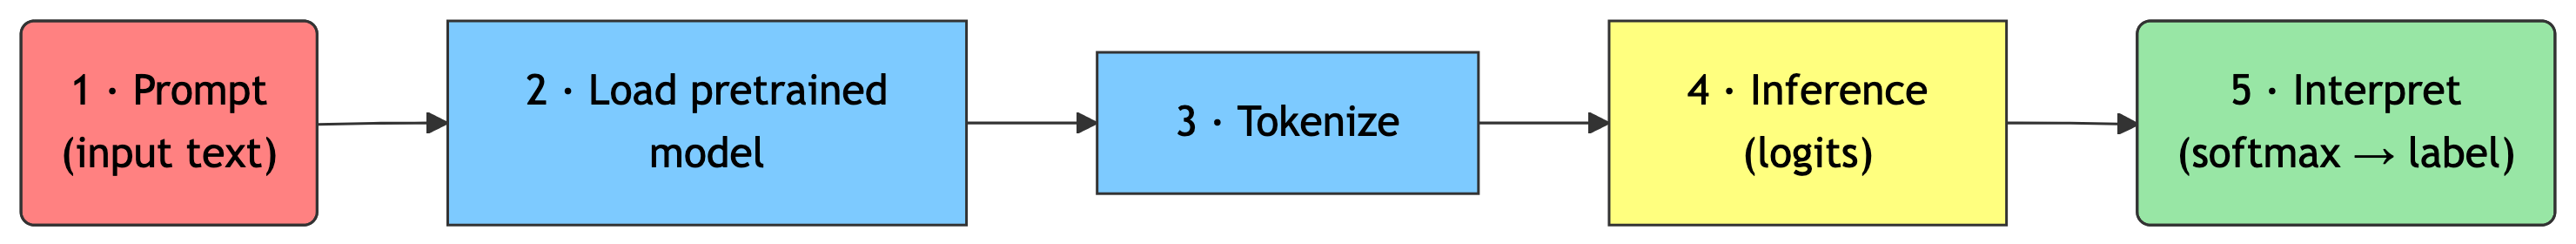
<figcaption>Figure 18: The five steps of a HuggingFace inference
pipeline.</figcaption>
</figure>

**Step 1 — Set up a prompt.** A *prompt* is the input provided to the
model; its structure guides the output.

In [22]:
input_text = "The panoramic view of the ocean was breathtaking."

**Step 2 — Load a pretrained model.** `from_pretrained()` downloads (and
caches) the model weights, config, and tokenizer from the HuggingFace
Model Hub. We use a DistilBERT model fine-tuned for sentiment (SST-2).
Heavy download, so display-only here:

In [23]:
import torch
import torch.nn.functional as F
from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
config = AutoConfig.from_pretrained(model_name)

**Step 3 — Tokenize the input.** Load the tokenizer that matches the
model and convert text to input IDs:

In [24]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
input_ids = tokenizer(input_text, return_tensors="pt")["input_ids"]
print(input_ids)

**Step 4 & 5 — Infer and interpret.** Run the model to get **logits**,
convert them to probabilities with softmax, and map the argmax to a
label:

In [25]:
outputs = model(input_ids)
logits = outputs.logits

probabilities = F.softmax(logits, dim=-1)
predicted_class = torch.argmax(probabilities, dim=-1).item()
labels = ["NEGATIVE", "POSITIVE"]
print(f"{labels[predicted_class]}  (score={probabilities[0][predicted_class]:.4f})")

> **⚡ The one-liner shortcut**
>
> For quick use, `pipeline()` wraps all five steps into a single call:
>
> ``` python
> from transformers import pipeline
>
> classifier = pipeline("sentiment-analysis")
> classifier("The panoramic view of the ocean was breathtaking.")
> # -> [{'label': 'POSITIVE', 'score': 0.9998}]
> ```

### Saving & loading models

A model (pretrained or fine-tuned) can be saved to and loaded from a
local directory:

In [27]:
from transformers import AutoModel, AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("bert-base-uncased")
# ... train or fine-tune ...
model.save_pretrained("my_local_model")           # save
loaded = AutoModel.from_pretrained("my_local_model")  # load back

### The Model Hub

The [🤗 Model Hub](https://huggingface.co/docs/hub/en/models-the-hub)
hosts hundreds of thousands of community model checkpoints. You can:

- Download pretrained models with `transformers` (for inference or
  fine-tuning).
- Filter by task, framework, dataset, language, and more.
- Read each model’s **model card** — description, intended use,
  limitations, and often a live inference widget.

## 🎒 Homework

1.  **Train the mini-LLM.** Run a training loop for the model above and
    plot how training and validation **perplexity** evolve. This helper
    will be useful:

    ``` python
    @torch.no_grad()
    def estimate_loss():
        out = {}
        model.eval()
        for split in ["train", "val"]:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                _, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
        model.train()
        return out
    ```

2.  **Sweep a hyperparameter.** Pick one of `n_embd`, `n_head`, or
    `n_layer` and train with ≥4 different values. Plot perplexity
    vs. training step for each.

3.  **Generate text** from each trained variant. Did some
    hyperparameters produce more coherent output than others?

4.  **Explore attention.** Use `bertviz` on a larger model (e.g.
    `meta-llama/Llama-2-7b-chat-hf`) and compare its attention patterns
    to GPT-2’s.

## 🌗 The Transformer Family

Not every Transformer is a decoder. The architecture splits into three
families, depending on which halves are used and how attention is
masked:

<figure id="fig-transformer-family">
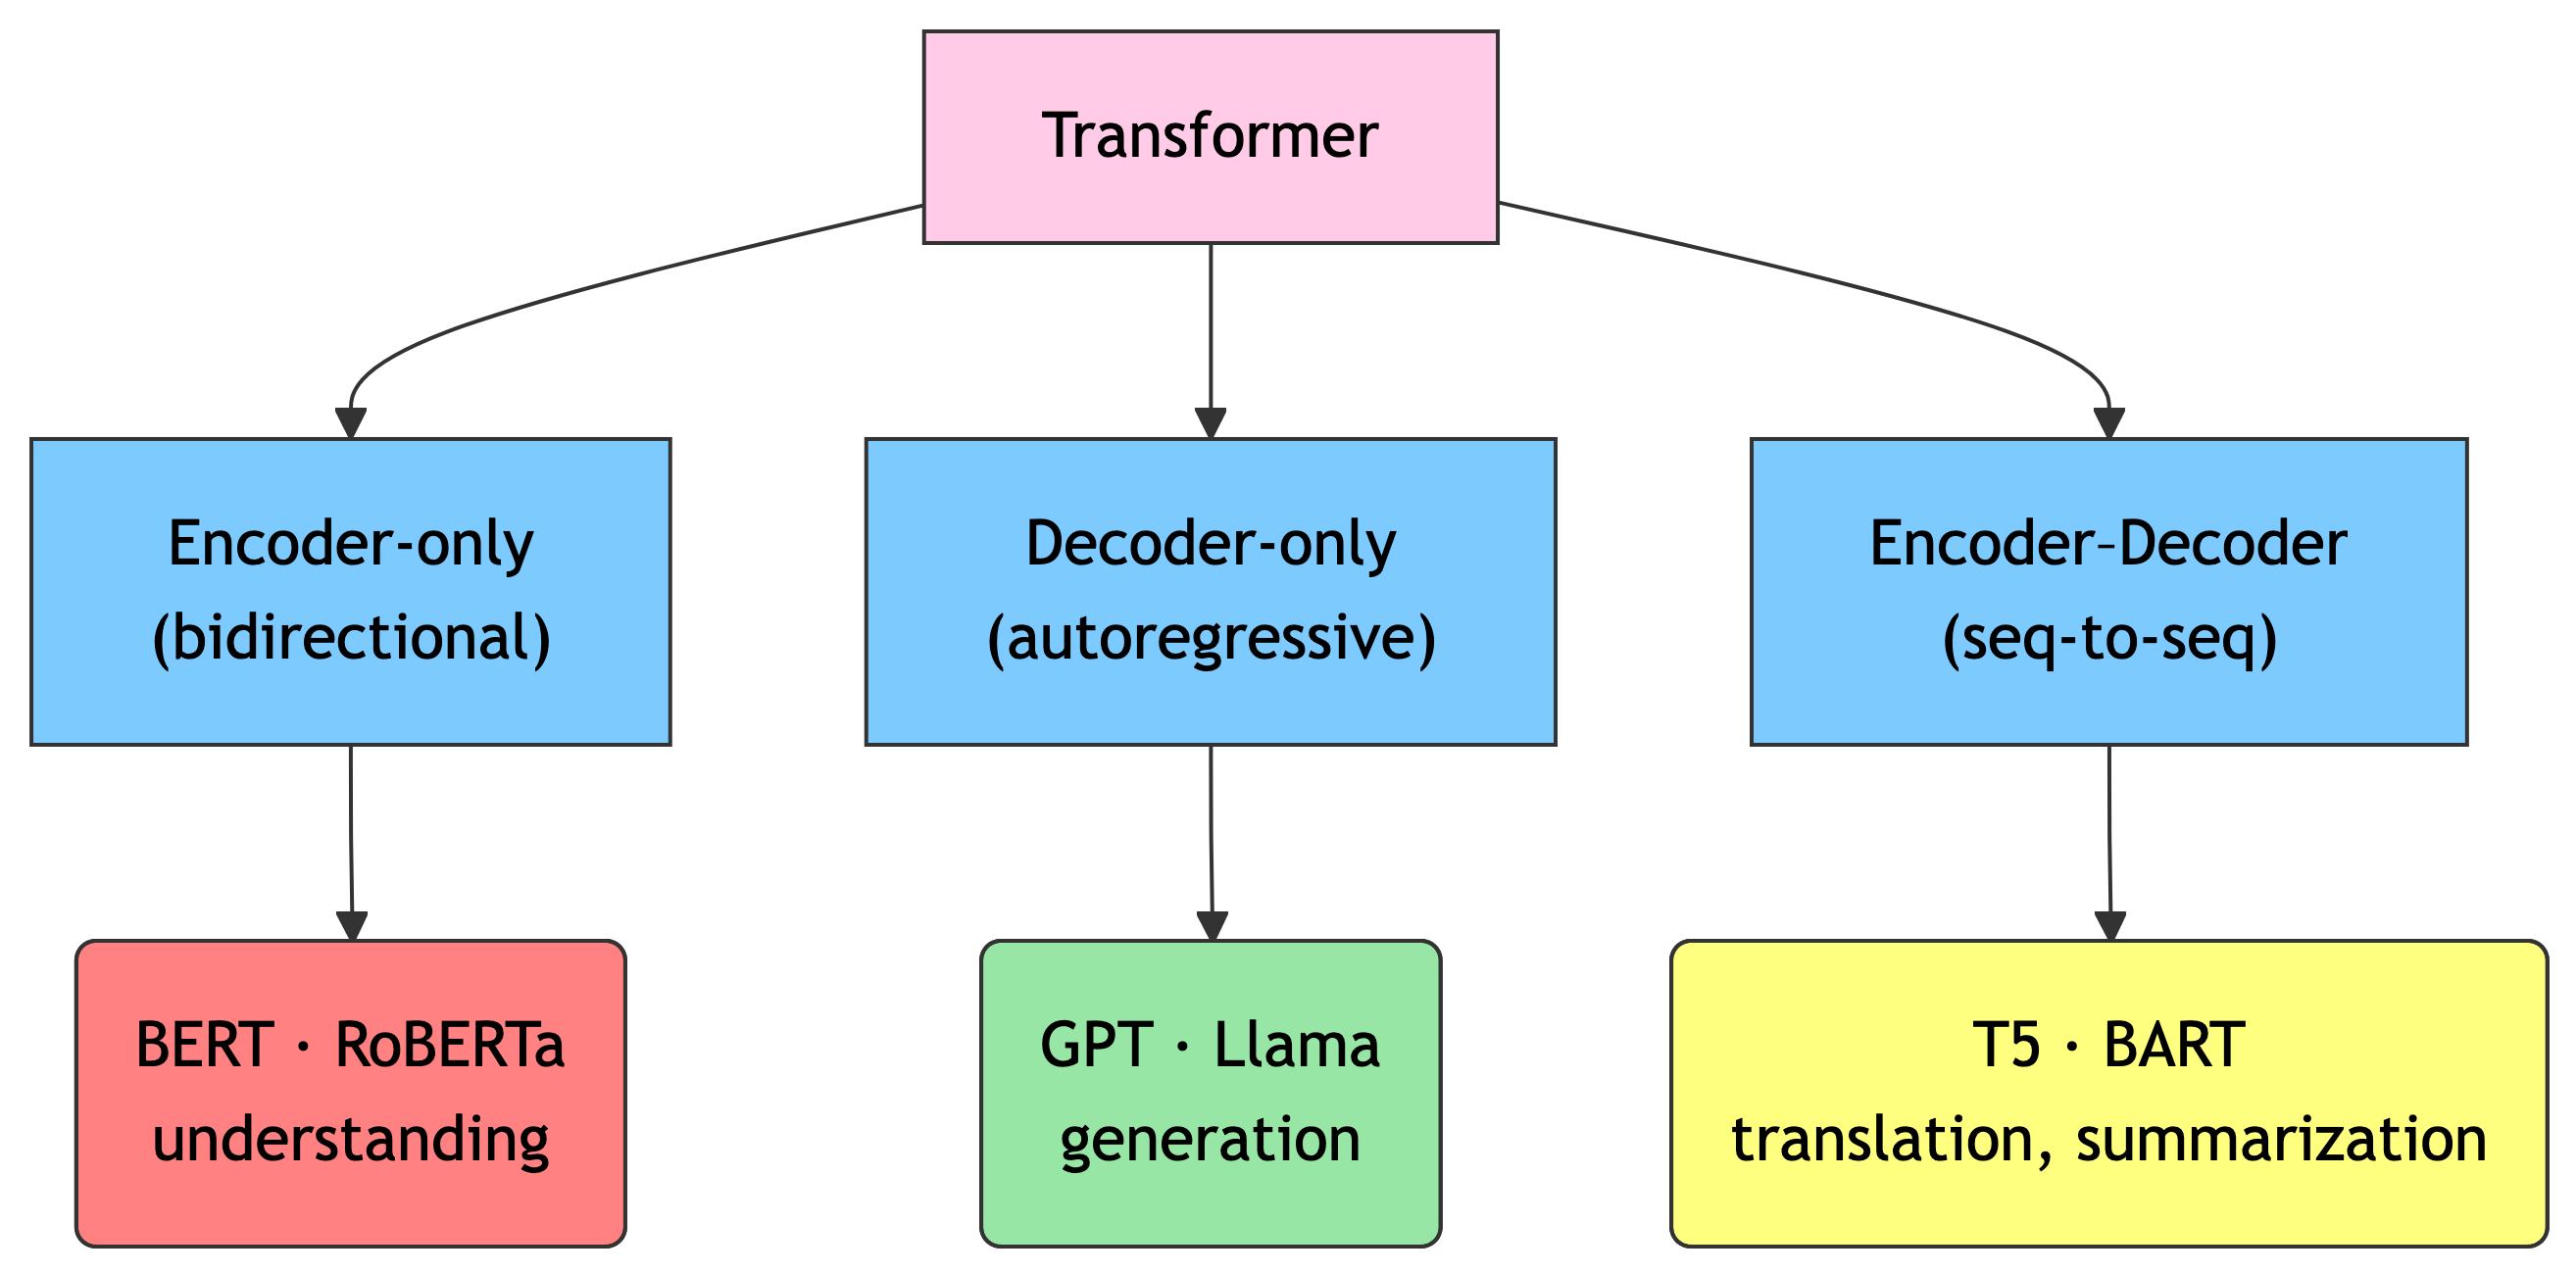
<figcaption>Figure 19: The three Transformer families and representative
models.</figcaption>
</figure>

### Encoder-only (BERT)

Encoder-only models use **bidirectional** attention — every token can
see the whole sentence. This makes them excellent for *understanding*
tasks (sentiment analysis, summarization inputs, disambiguation) but
poor at open-ended generation.

<figure id="fig-bert">
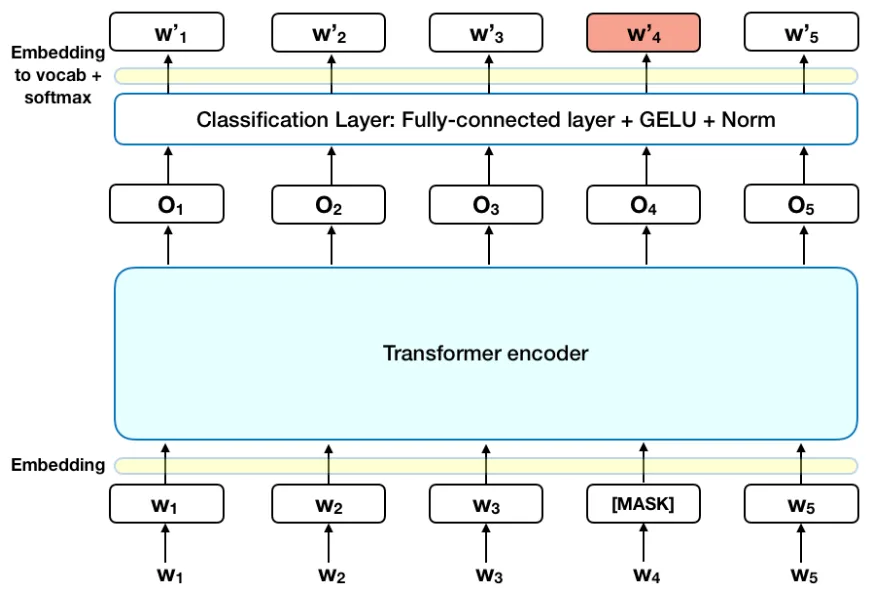
<figcaption>Figure 20: BERT reads the entire sequence at once
(bidirectional). Image credit: <a
href="https://towardsdatascience.com/bert-explained-state-of-the-art-language-model-for-nlp-f8b21a9b6270">Towards
Data Science</a>.</figcaption>
</figure>

BERT is trained with two objectives: **masked language modeling**
(predict hidden words) and **next-sentence prediction**. Its input is
built with special tokens — `[CLS]` at the start and `[SEP]`
between/after sentences — plus segment and positional embeddings.

<figure id="fig-bert-input">
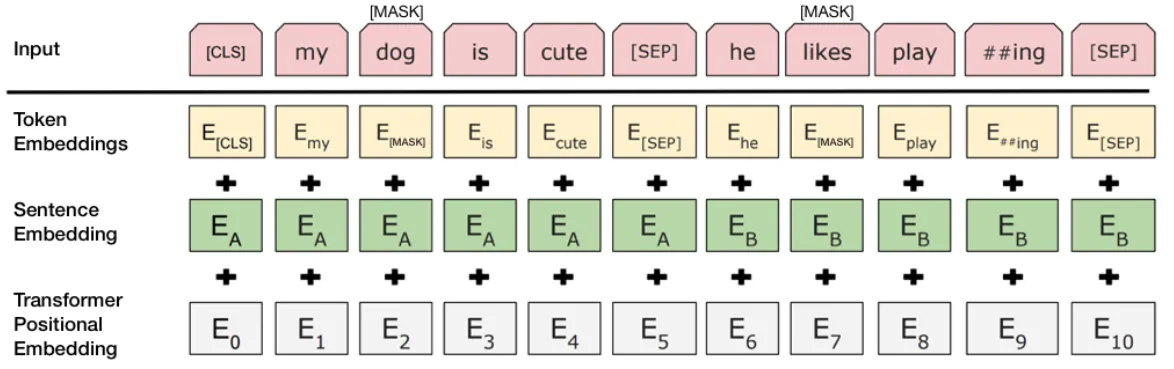
<figcaption>Figure 21: BERT input construction. Image credit: <a
href="https://towardsdatascience.com/bert-explained-state-of-the-art-language-model-for-nlp-f8b21a9b6270">Towards
Data Science</a>.</figcaption>
</figure>

|           | **Encoder-only (BERT)** | **Decoder-only (GPT)** |
|:----------|:------------------------|:-----------------------|
| Attention | Bidirectional           | Masked (causal)        |
| Best at   | Understanding           | Generation             |
| Training  | Masked LM + NSP         | Next-token prediction  |
| Examples  | BERT, RoBERTa, ALBERT   | GPT, Llama, CTRL       |

Encoder-only vs. decoder-only Transformers {.table-responsive
.table-striped .table-hover}

### Decoder-only (GPT)

As we saw, decoder-only models use **masked self-attention** so a token
attends only to earlier positions — essential for learning generation
without “peeking” at the answer.

<figure id="fig-masked-attention">
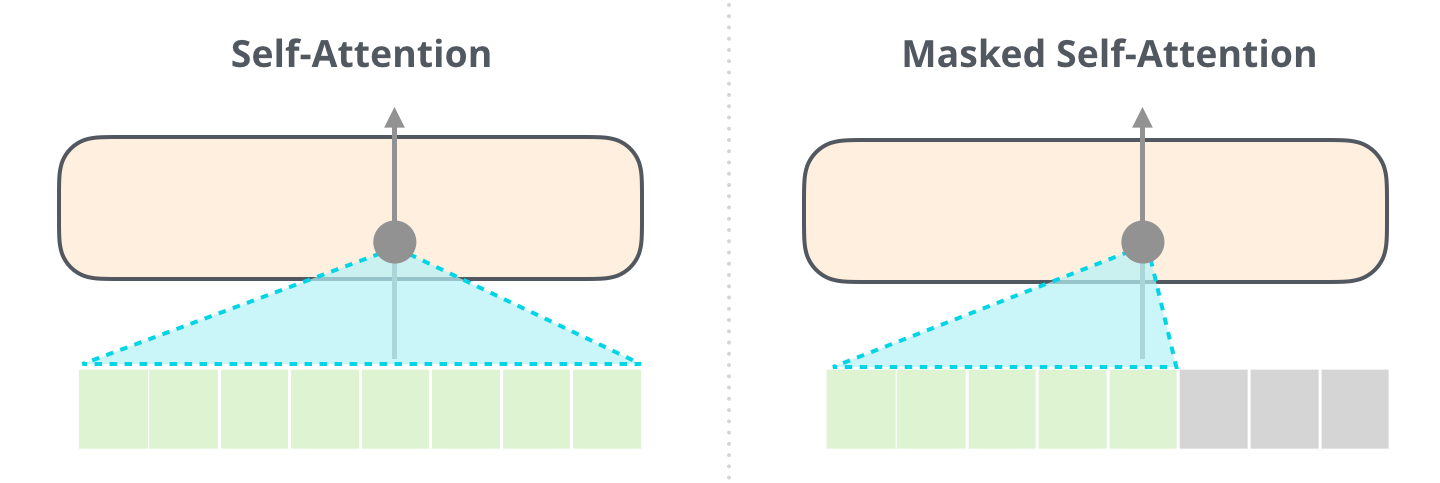
<figcaption>Figure 22: Full (bidirectional) vs. masked self-attention.
Image credit: <a href="https://jalammar.github.io/illustrated-gpt2/">Jay
Alammar</a>.</figcaption>
</figure>

### Beyond text: Vision & Graph Transformers

The Transformer is modality-agnostic. **Vision Transformers (ViT)**
split an image into patches, embed each patch (plus a positional
encoding), and feed the sequence to a Transformer encoder.

<figure id="fig-vit">
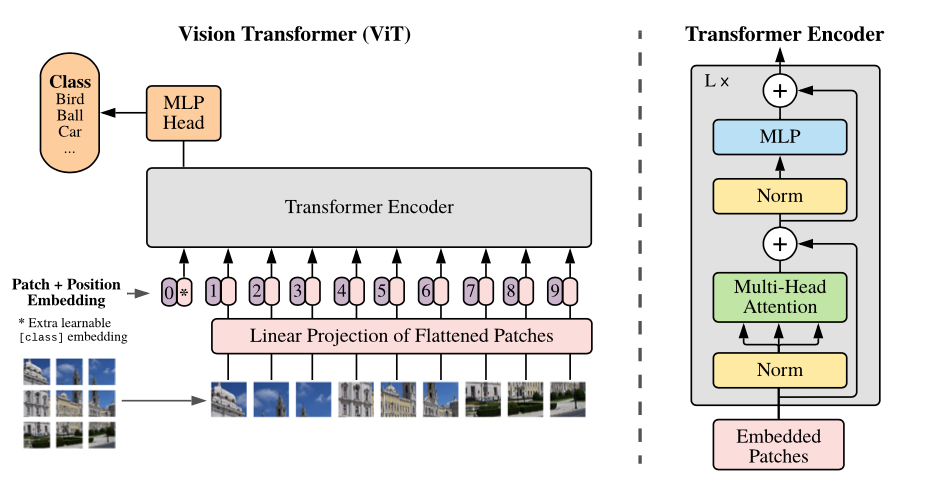
<figcaption>Figure 23: Vision Transformer. Image credit: Dosovitskiy et
al., <a href="https://arxiv.org/abs/2010.11929"><em>An Image is Worth
16×16 Words</em></a> (2020).</figcaption>
</figure>

**Graph Transformers** extend attention to graph-structured data
(molecules, interaction networks).

<figure id="fig-graphformer">
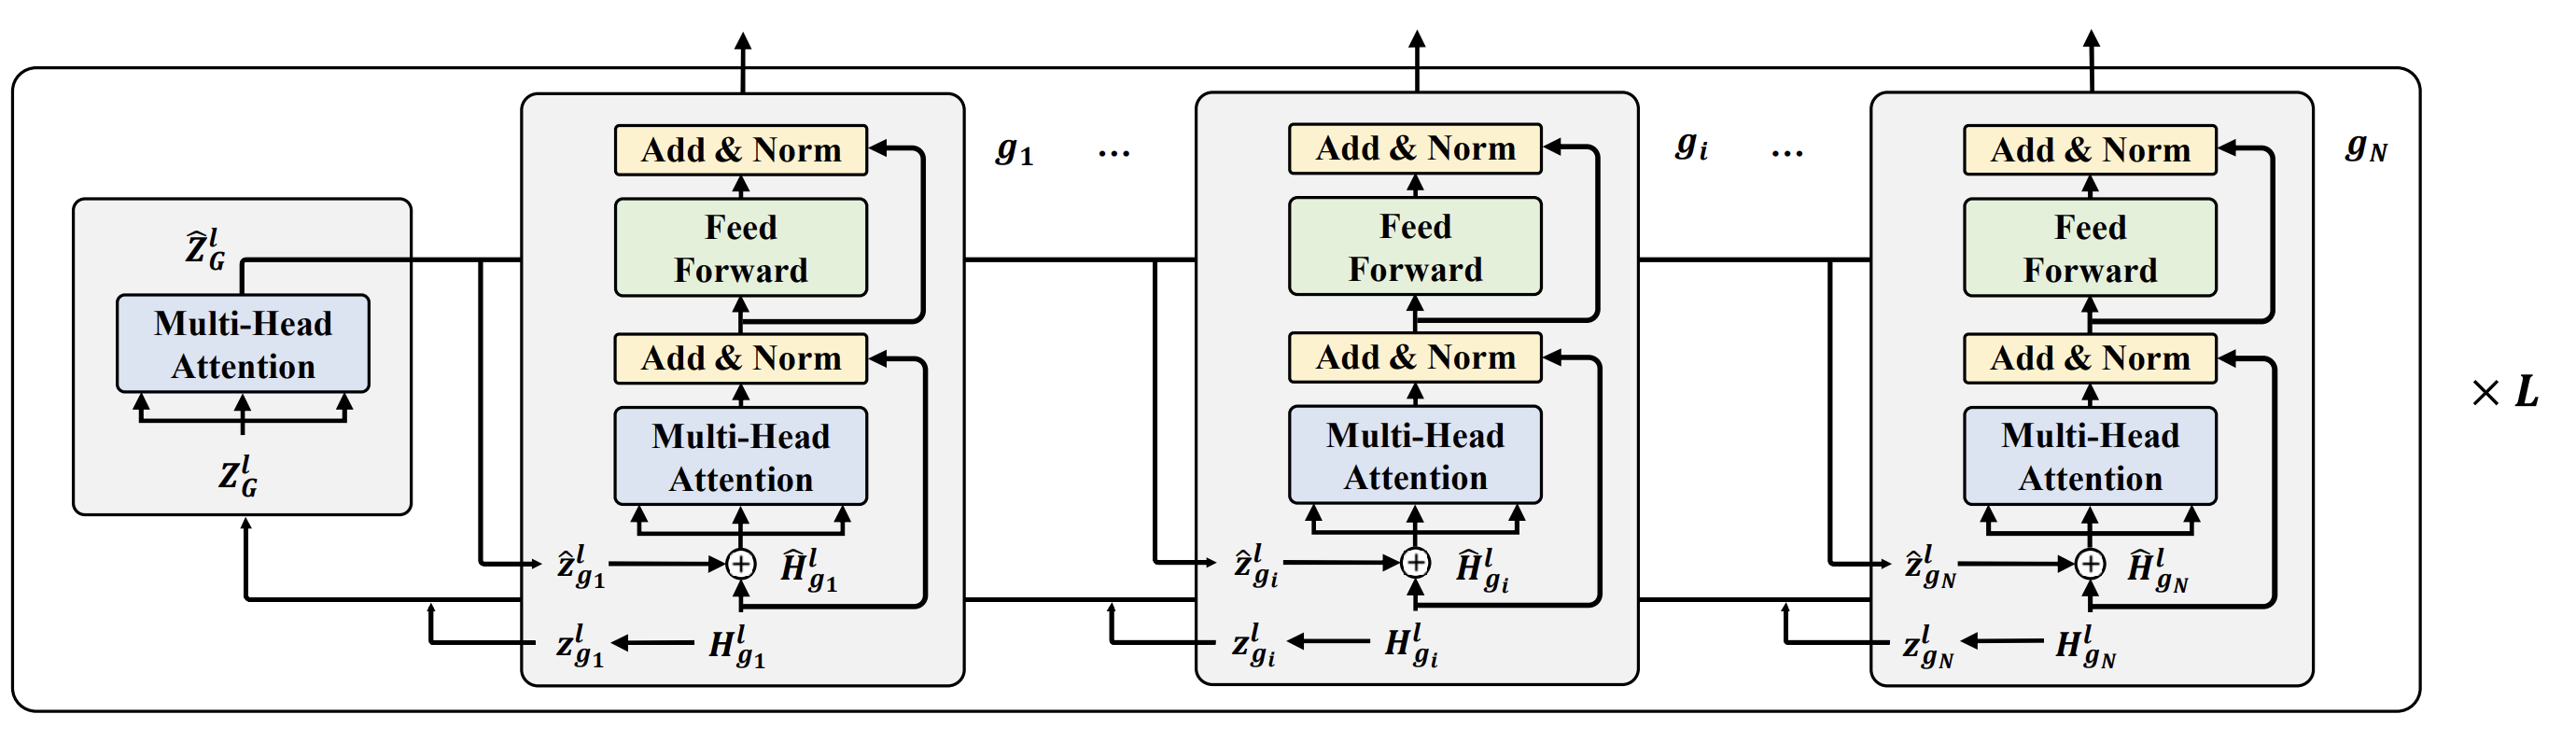
<figcaption>Figure 24: A Graph Transformer.</figcaption>
</figure>

## ✅ Key Takeaways

> **Recap**
>
> - **Sequences are everywhere** — text, DNA, proteins, molecules, time
>   series.
> - **Attention replaced recurrence**, enabling parallel training and
>   long-range context — the breakthrough behind LLMs.
> - Text becomes numbers via **tokenization** → **embeddings** (learned
>   geometry).
> - A Transformer block = **masked self-attention** + **feed-forward**,
>   with residuals and layer-norm, repeated `N` times.
> - Models are trained to minimize **cross-entropy** (≈ minimize
>   **perplexity**).
> - Three families — **encoder-only** (understand), **decoder-only**
>   (generate), **encoder–decoder** (translate) — plus vision and graph
>   variants.

## 📚 References & Further Reading

- Vaswani et al., [*Attention Is All You
  Need*](https://arxiv.org/abs/1706.03762) (2017)
- Jay Alammar, [The Illustrated
  Transformer](https://jalammar.github.io/illustrated-transformer/)
- Jay Alammar, [The Illustrated
  GPT-2](https://jalammar.github.io/illustrated-gpt2/)
- Jay Alammar, [Visualizing Neural Machine Translation (seq2seq +
  attention)](https://jalammar.github.io/visualizing-neural-machine-translation-mechanics-of-seq2seq-models-with-attention/)
- 🤗 [HuggingFace LLM
  Course](https://huggingface.co/learn/llm-course/chapter1/1)
- [A Gentle Introduction to Positional
  Encoding](https://machinelearningmastery.com/a-gentle-introduction-to-positional-encoding-in-transformer-models-part-1/)
- Jay Mody, [GPT in 60 Lines of
  NumPy](https://jaykmody.com/blog/gpt-from-scratch/)
- Andrej Karpathy, [Let’s build GPT
  (nanoGPT)](https://www.youtube.com/watch?v=kCc8FmEb1nY) — the
  tiny-Shakespeare model above is based on this